In [106]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:34895")
client

OSError: Timed out trying to connect to tcp://127.0.0.1:34895 after 30 s

In [2]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46013 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46013/status,
Dashboard: http://127.0.0.1:46013/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46195,Workers: 56
Dashboard: http://127.0.0.1:46013/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:45367,Total threads: 1
Dashboard: http://127.0.0.1:44065/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:44003,


In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from string import ascii_lowercase, ascii_uppercase

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from aostools import climate


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [4]:
xr.set_options(keep_attrs=True)
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
plt.rcParams.update({"font.size": 18})

In [5]:
def process(ds, sel_var, deseasonalize=True):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    ds = ds.rename({'var130': 't'})
    if isinstance(sel_var, list): 
        ds = ds[sel_var]
    else:
        ds = ds[[sel_var]]


    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.drop_duplicates("plev").sortby(["plev", "lat"]).squeeze()

def process_chem(ds, deseasonalize=True, upper_limit=0.1, lower_limit=300):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))


def add_div(ds):
    ds_out = ds["div1"] + ds["div2"]
    return ds_out

# https://wiki.mpimet.mpg.de/doku.php?id=analysis:pot_pourri:statistics:controlling_fdr
def xr_multipletest(p, alpha=0.05, method="fdr_bh", **multipletests_kwargs):
    """Apply statsmodels.stats.multitest.multipletests for multi-dimensional xr.objects."""
    from statsmodels.stats.multitest import multipletests

    # stack all to 1d array
    p_stacked = p.stack(s=p.dims)
    # mask only where not nan: https://github.com/statsmodels/statsmodels/issues/2899
    mask = np.isfinite(p_stacked)
    pvals_corrected = np.full(p_stacked.shape, np.nan)
    reject = np.full(p_stacked.shape, np.nan)
    # apply test where mask
    reject[mask] = multipletests(
        p_stacked[mask], alpha=alpha, method=method, **multipletests_kwargs
    )[0]
    pvals_corrected[mask] = multipletests(
        p_stacked[mask], alpha=alpha, method=method, **multipletests_kwargs
    )[1]

    def unstack(reject, p_stacked):
        """Exchange values from p_stacked with reject (1d array) and unstack."""
        xreject = p_stacked.copy()
        xreject.values = reject
        xreject = xreject.unstack()
        return xreject

    reject = unstack(reject, p_stacked)
    pvals_corrected = unstack(pvals_corrected, p_stacked)
    return reject, pvals_corrected

# Analysis

## NAM

In [4]:
nam_wo = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt2-all_NAM_2021-2025.nc')['nam']
nam_w = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt1-all_NAM_2021-2025.nc')['nam']

In [112]:
diff = nam_w.mean("ens") - nam_wo.mean("ens")
_, p_values = stats.ttest_ind(nam_w, nam_wo, equal_var=False)
diff_pv = xr.DataArray(p_values, coords=diff.coords)
diff_pv_fdr = xr_multipletest(diff_pv)[1]

### all seasons

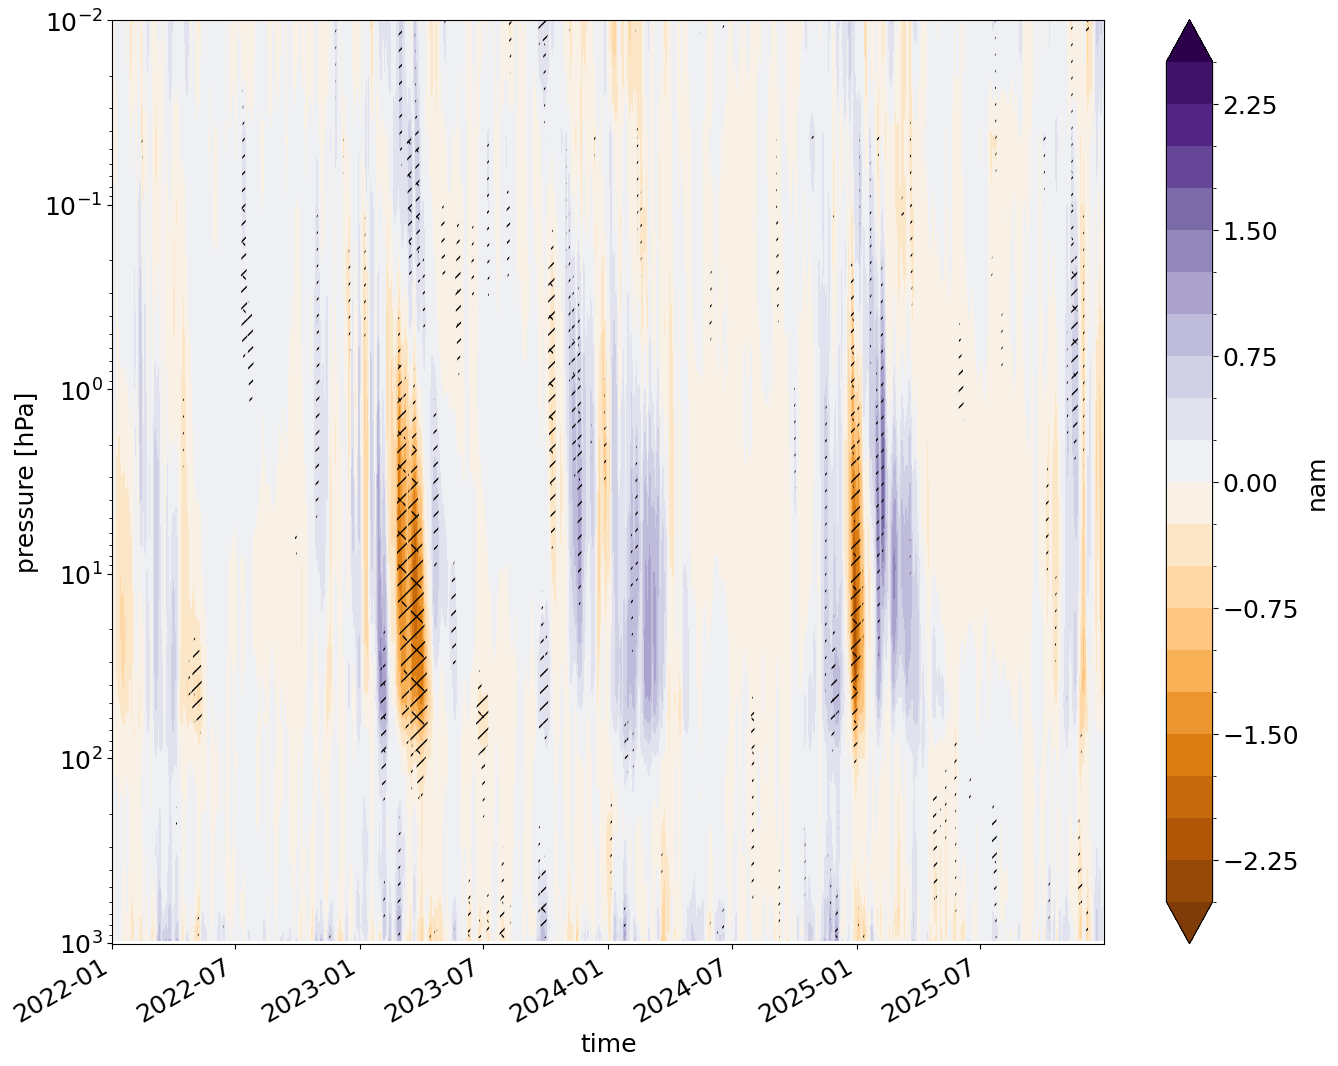

In [11]:
p = diff.plot.contourf(x="time", yincrease=False, levels=21, robust=False, size=12, extend = 'both', cmap="PuOr")
ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.01]
kwargs['hatches'] = ["\\",  None]
diff_pv.plot.contourf(x="time", ax=ax, **kwargs)
plt.yscale("log")

### 2022/2023

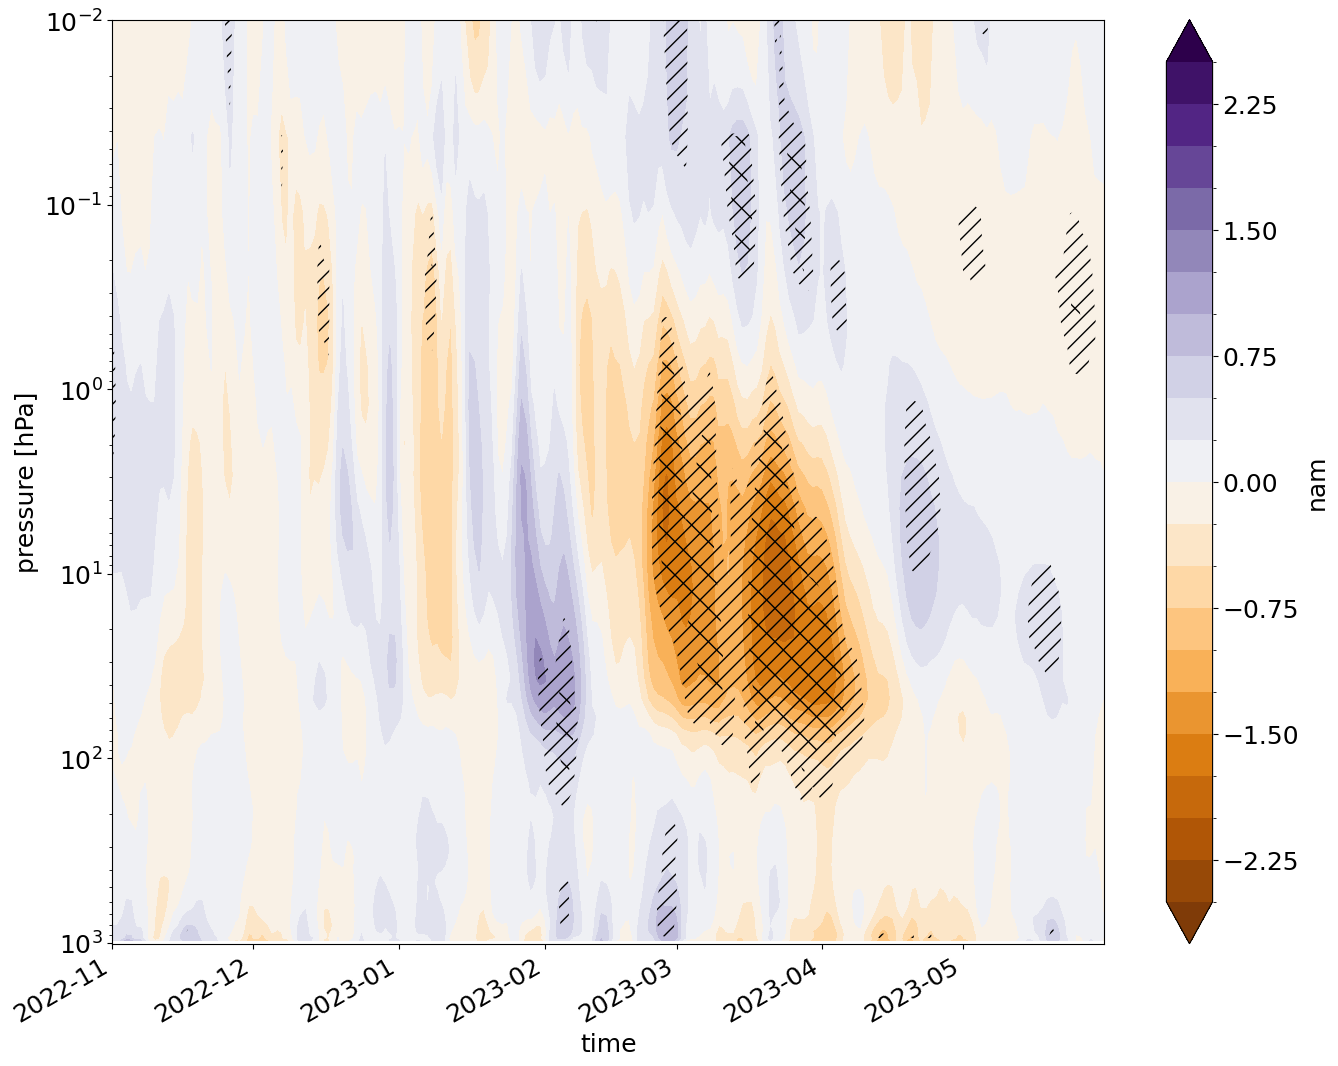

In [12]:
sel_dict = dict(time=slice("2022-11", "2023-05"))
p= diff.sel(**sel_dict).plot.contourf(
    x="time", yincrease=False, levels=21, size=12, vmax = p.colorbar.vmax, extend = 'both', cmap="PuOr"
)

ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.01]
kwargs['hatches'] = ["\\",  None]
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)

plt.yscale("log")

### 2023/2024

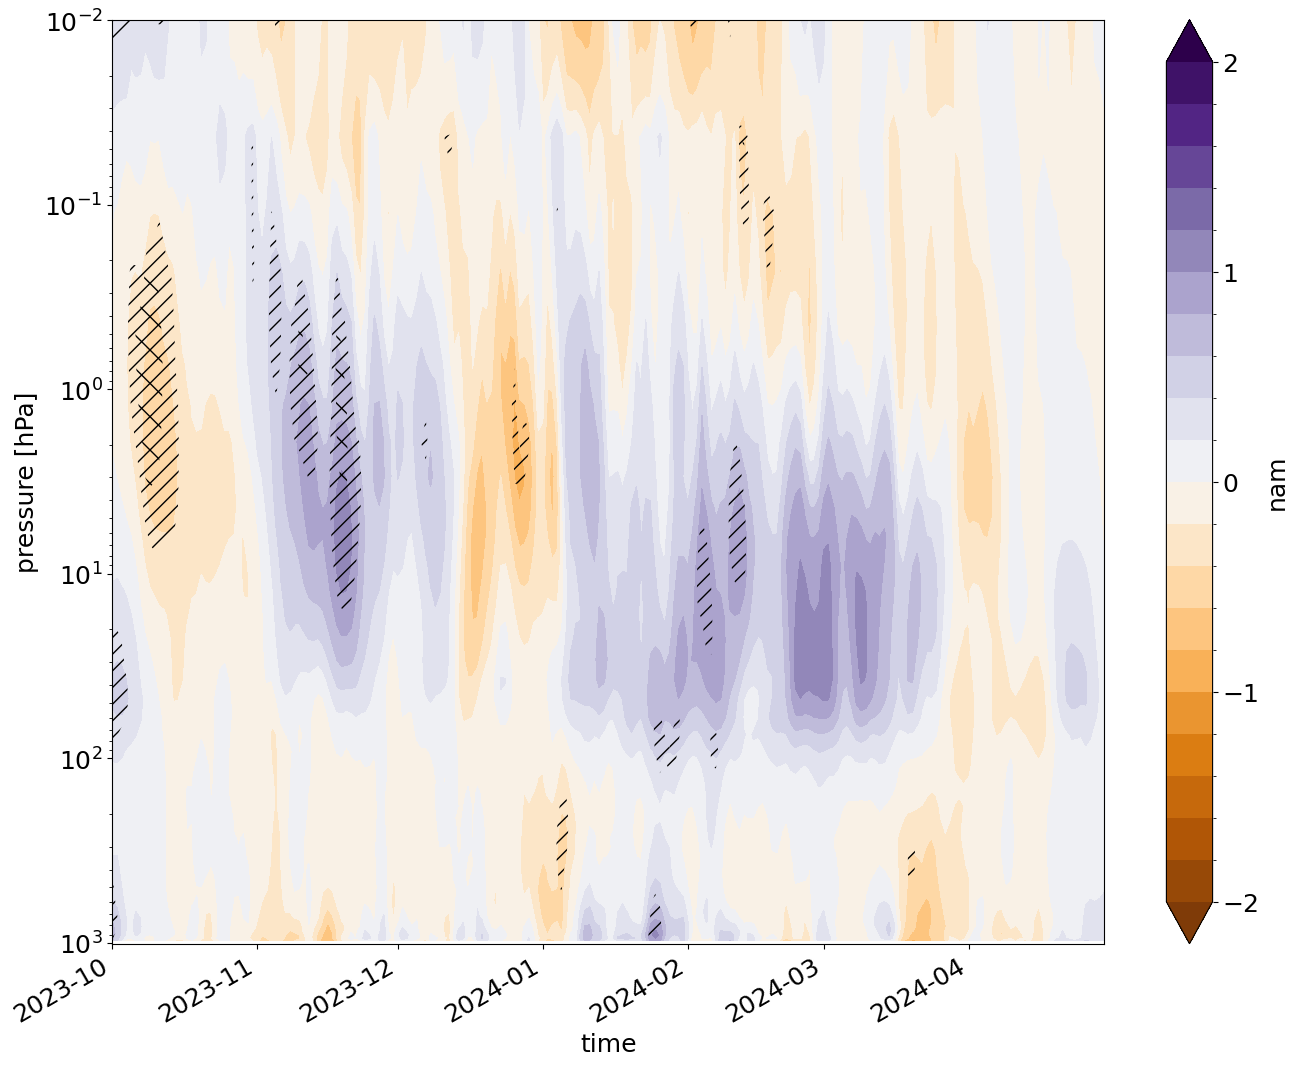

In [92]:
sel_dict = dict(time=slice("2023-10", "2024-04"))
cbar_kwargs = dict(ticks = [-2,-1,0,1,2])
p= diff.sel(**sel_dict).plot.contourf(
    x="time", yincrease=False, levels=21, size=12, vmax = 2, extend = 'both', cmap="PuOr",
    cbar_kwargs=cbar_kwargs
)

ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.01]
kwargs['hatches'] = ["\\",  None]
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)

kwargs = dict(
    yincrease= False,
    colors=("k"),
    add_colorbar=False,
    levels=[0, 0.3],
)
diff_pv_fdr.sel(**sel_dict).plot.contour(x="time", ax=ax, **kwargs)

plt.yscale("log")

### 2024-2025

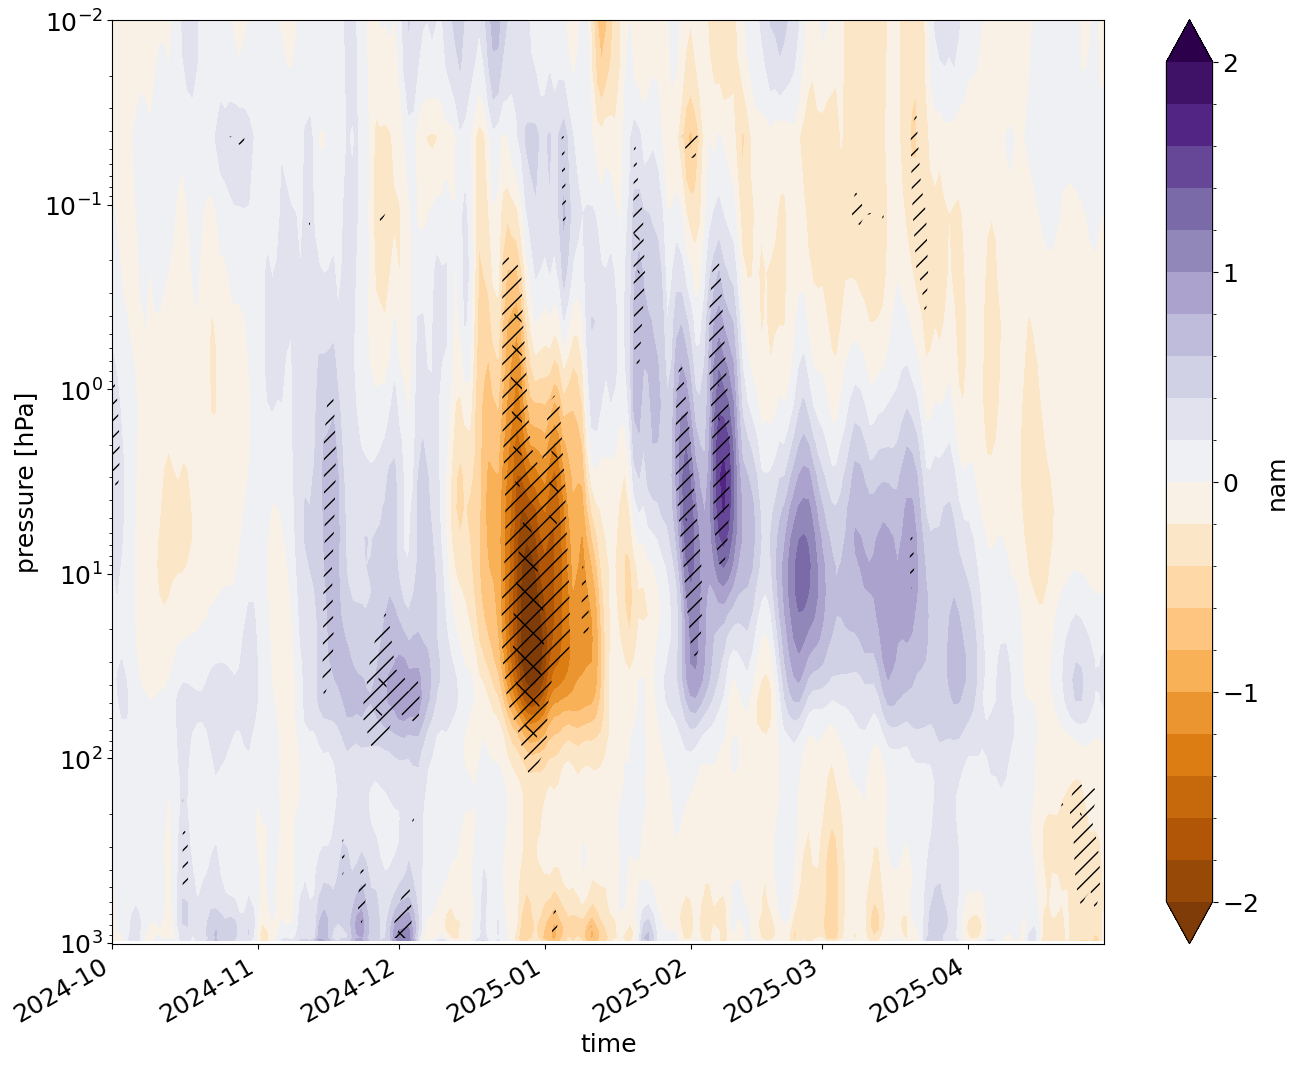

In [113]:
sel_dict = dict(time=slice("2024-10", "2025-04"))
cbar_kwargs = dict(ticks = [-2,-1,0,1,2])
p= diff.sel(**sel_dict).plot.contourf(
    x="time", yincrease=False, levels=21, size=12, vmax = 2, extend = 'both', cmap="PuOr",
    cbar_kwargs=cbar_kwargs
)

ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.01]
kwargs['hatches'] = ["\\",  None]
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)

kwargs = dict(
    yincrease= False,
    colors=("k"),
    add_colorbar=False,
    levels=[0, 0.3],
)
diff_pv_fdr.sel(**sel_dict).plot.contour(x="time", ax=ax, **kwargs)

plt.yscale("log")

Text(0.65, 0.85, 't-test p-value=2.498e-22')

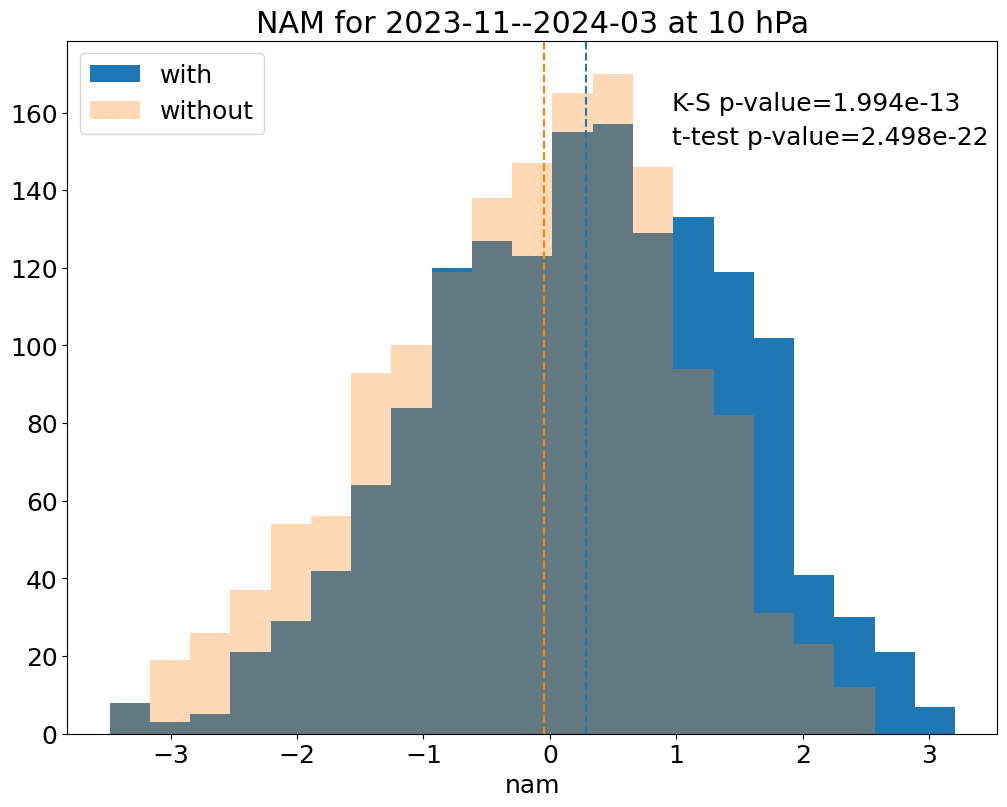

In [64]:
sel_dict = dict(time=slice("2023-11", "2024-03"), plev = 9.010901) # NDJFM

fig, ax = plt.subplots(figsize = (12,9))

arr1 = nam_w.sel(**sel_dict)
hists = arr1.plot.hist(bins = 21, label = 'with')
plt.axvline(arr1.median(), ls = 'dashed', color = 'C0')

arr2 = nam_wo.sel(**sel_dict)
arr2.plot.hist(bins = hists[1], alpha = 0.3, label = 'without')
plt.axvline(arr2.median(), ls = 'dashed', color = 'C1')
plt.legend()
plt.title(f"NAM for {sel_dict['time'].start}--{sel_dict['time'].stop} at 10 hPa")

pv = stats.ks_2samp(arr1.values.flatten(), arr2.values.flatten()).pvalue
ax.text(0.65, 0.9, f"K-S p-value={pv:.3e}", transform=ax.transAxes)
pv = stats.ttest_ind(arr1.values.flatten(), arr2.values.flatten(), equal_var=False).pvalue
ax.text(0.65, 0.85, f"t-test p-value={pv:.3e}", transform=ax.transAxes)


Text(0.65, 0.85, 't-test p-value=9.834e-02')

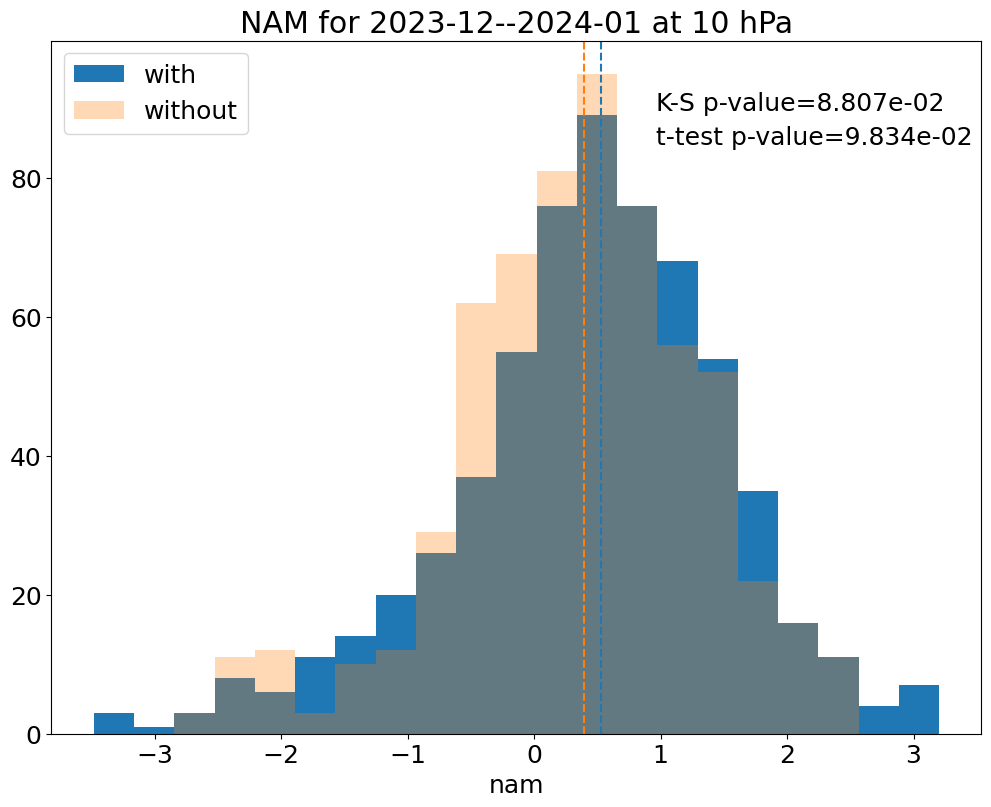

In [67]:
sel_dict = dict(time=slice("2023-12", "2024-01"), plev = 9.010901) # NDJFM

fig, ax = plt.subplots(figsize = (12,9))

arr1 = nam_w.sel(**sel_dict)
hists = arr1.plot.hist(bins = 21, label = 'with')
plt.axvline(arr1.median(), ls = 'dashed', color = 'C0')

arr2 = nam_wo.sel(**sel_dict)
arr2.plot.hist(bins = hists[1], alpha = 0.3, label = 'without')
plt.axvline(arr2.median(), ls = 'dashed', color = 'C1')
plt.legend()
plt.title(f"NAM for {sel_dict['time'].start}--{sel_dict['time'].stop} at 10 hPa")

pv = stats.ks_2samp(arr1.values.flatten(), arr2.values.flatten()).pvalue
ax.text(0.65, 0.9, f"K-S p-value={pv:.3e}", transform=ax.transAxes)
pv = stats.ttest_ind(arr1.values.flatten(), arr2.values.flatten(), equal_var=False).pvalue
ax.text(0.65, 0.85, f"t-test p-value={pv:.3e}", transform=ax.transAxes)


Text(0.65, 0.85, 't-test p-value=3.853e-06')

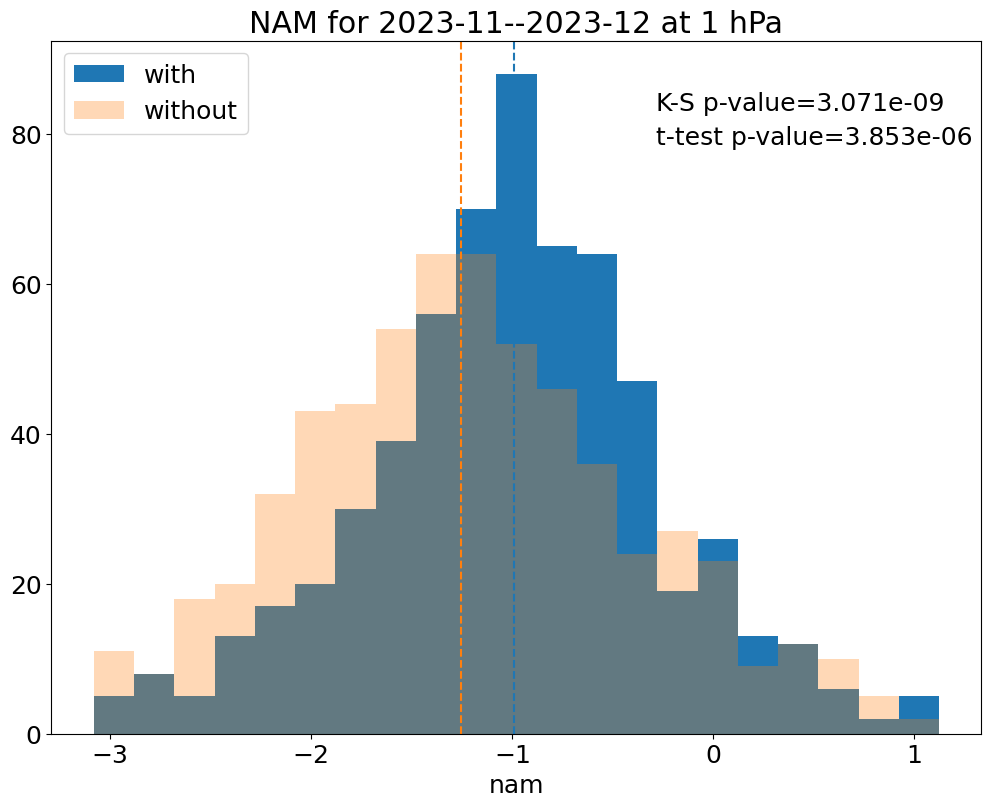

In [88]:
sel_dict = dict(time=slice("2023-11", "2023-12")) # NDJFM

fig, ax = plt.subplots(figsize = (12,9))

arr1 = nam_w.sel(**sel_dict)[...,6]
hists = arr1.plot.hist(bins = 21, label = 'with')
plt.axvline(arr1.median(), ls = 'dashed', color = 'C0')

arr2 = nam_wo.sel(**sel_dict)[...,6]
arr2.plot.hist(bins = hists[1], alpha = 0.3, label = 'without')
plt.axvline(arr2.median(), ls = 'dashed', color = 'C1')
plt.legend()
plt.title(f"NAM for {sel_dict['time'].start}--{sel_dict['time'].stop} at 1 hPa")

pv = stats.ks_2samp(arr1.values.flatten(), arr2.values.flatten()).pvalue
ax.text(0.65, 0.9, f"K-S p-value={pv:.3e}", transform=ax.transAxes)
pv = stats.ttest_ind(arr1.values.flatten(), arr2.values.flatten(), equal_var=False).pvalue
ax.text(0.65, 0.85, f"t-test p-value={pv:.3e}", transform=ax.transAxes)


Text(0.65, 0.85, 't-test p-value=1.001e-21')

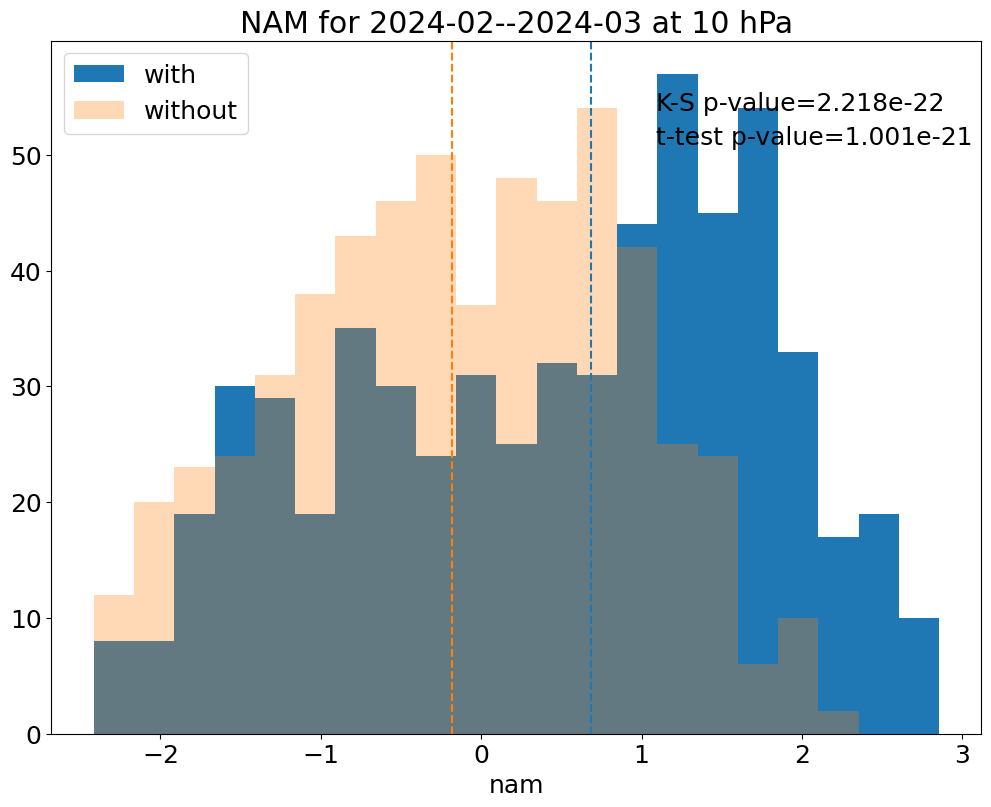

In [66]:
sel_dict = dict(time=slice("2024-02", "2024-03"), plev = 9.010901) # NDJFM

fig, ax = plt.subplots(figsize = (12,9))

arr1 = nam_w.sel(**sel_dict)
hists = arr1.plot.hist(bins = 21, label = 'with')
plt.axvline(arr1.median(), ls = 'dashed', color = 'C0')

arr2 = nam_wo.sel(**sel_dict)
arr2.plot.hist(bins = hists[1], alpha = 0.3, label = 'without')
plt.axvline(arr2.median(), ls = 'dashed', color = 'C1')
plt.legend()
plt.title(f"NAM for {sel_dict['time'].start}--{sel_dict['time'].stop} at 10 hPa")

pv = stats.ks_2samp(arr1.values.flatten(), arr2.values.flatten()).pvalue
ax.text(0.65, 0.9, f"K-S p-value={pv:.3e}", transform=ax.transAxes)
pv = stats.ttest_ind(arr1.values.flatten(), arr2.values.flatten(), equal_var=False).pvalue
ax.text(0.65, 0.85, f"t-test p-value={pv:.3e}", transform=ax.transAxes)


In [33]:
stats.ks_2samp(arr1.values.flatten(), arr2.values.flatten())

KstestResult(statistic=0.1401315789473684, pvalue=1.9940716345332758e-13, statistic_location=0.9269828202620729, statistic_sign=-1)

Text(0, 0.5, 'NAM index')

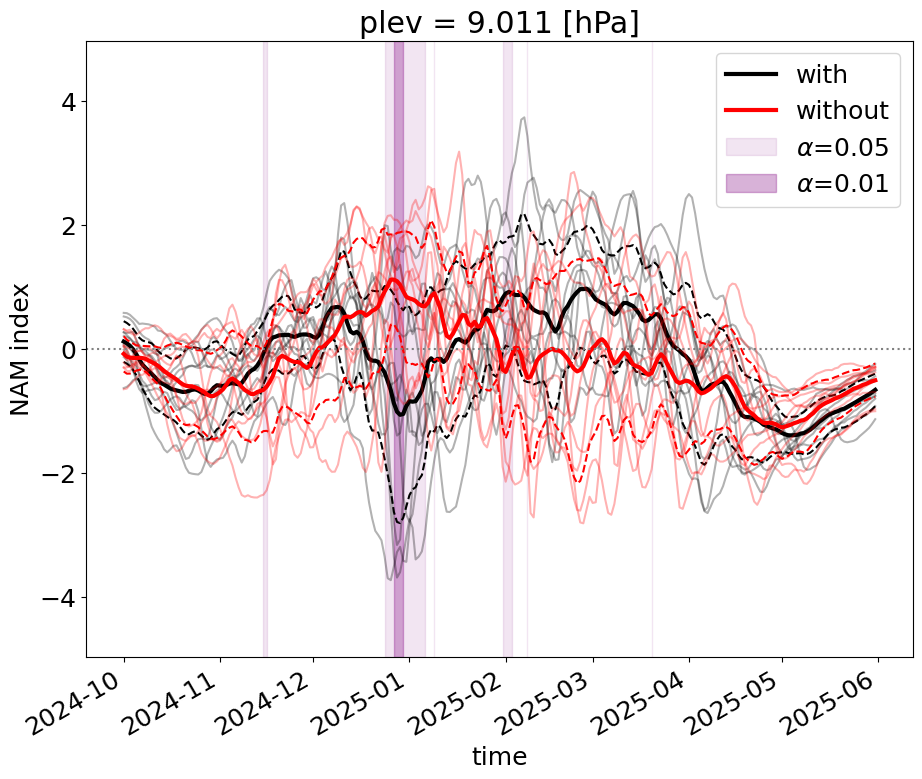

In [186]:
temp1 = nam_w.sel(**sel_dict).sel(plev = 10, method = 'nearest')
p = temp1.plot.line(color="k", alpha=0.3, hue="ens", add_legend=False, size=8)
m = temp1.mean("ens")
s1 = temp1.std('ens')
m.plot(color="k", lw=3, label="with")
upper = m+s1
lower = m-s1
upper.plot(color="k", ls = 'dashed')
lower.plot(color="k", ls = 'dashed')

temp2 = nam_wo.sel(**sel_dict).sel(plev = 10, method = 'nearest')
temp2.plot.line(color="r", alpha=0.3, hue="ens", add_legend=False)
m = temp2.mean("ens")
s2 = temp2.std('ens')
m.plot(color="r", lw=3, label="without")


upper = m+s2
lower = m-s2
upper.plot(color="r", ls = 'dashed')
lower.plot(color="r", ls = 'dashed')

alpha = 0.05
t_stat, p_values = stats.ttest_ind(temp1, temp2, equal_var=False)
diff_pv = xr.DataArray(p_values, coords=temp1.mean("ens").coords)
p_values_fdr = xr_multipletest(diff_pv)[1]

x_date = (
    temp1.time.values
)  # temp1.mean("ens").where(p_values < alpha).dropna('time').time.values

alpha = 0.05
mask = p_values < alpha
#mask = p_values_fdr < alpha
#print(x_date[mask])
# plt.plot(x_date, [2.5]*len(x_date), color = 'k', marker = 'x', ms = 12, ls = 'None', label = f'alpha<{alpha}')
# plt.fill_between(x_date, -2, 2, color = 'gray', alpha = 0.3)
# alpha = 0.01
# x_date = temp1.mean("ens").where(p_values < alpha).dropna('time').time.values
ax = p[0].axes
ax.fill_between(
    x_date,
    0,
    1,
    where=mask,
    color="purple",
    alpha=0.1,
    transform=ax.get_xaxis_transform(),
    label=r"$\alpha$" + f"={alpha}",
)

alpha = 0.01
mask = p_values < alpha
#mask = p_values_fdr < alpha
ax.fill_between(
    x_date,
    0,
    1,
    where=mask,
    color="purple",
    alpha=0.3,
    transform=ax.get_xaxis_transform(),
    label=r"$\alpha$" + f"={alpha}",
)
"""
alpha = .3
mask = p_values_fdr < alpha
print(x_date[mask])
ax.fill_between(
    x_date,
    0,
    1,
    where=mask,
    color="purple",
    alpha=0.5,
    transform=ax.get_xaxis_transform(),
    label=r"$\alpha_{FDR}$" + f"={alpha}",
)
"""
plt.axhline(0, ls=":", c="gray")
plt.legend()
plt.ylabel("NAM index")

In [191]:
res = stats.ks_2samp(temp1, temp2)

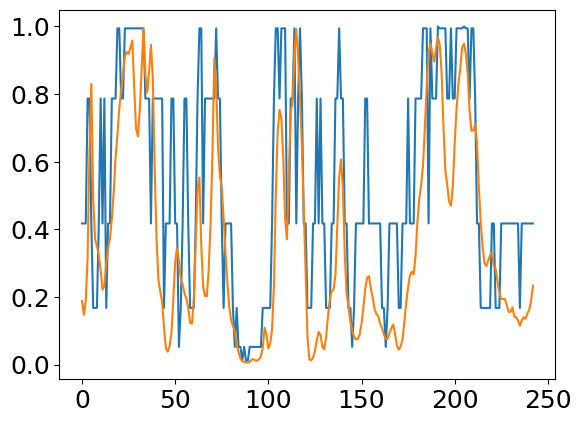

In [194]:
plt.plot(res.pvalue)
plt.plot(p_values)

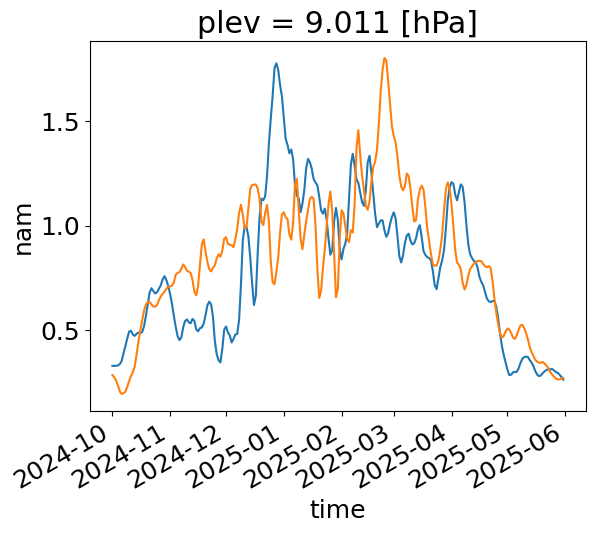

In [189]:
s1.plot()
s2.plot()

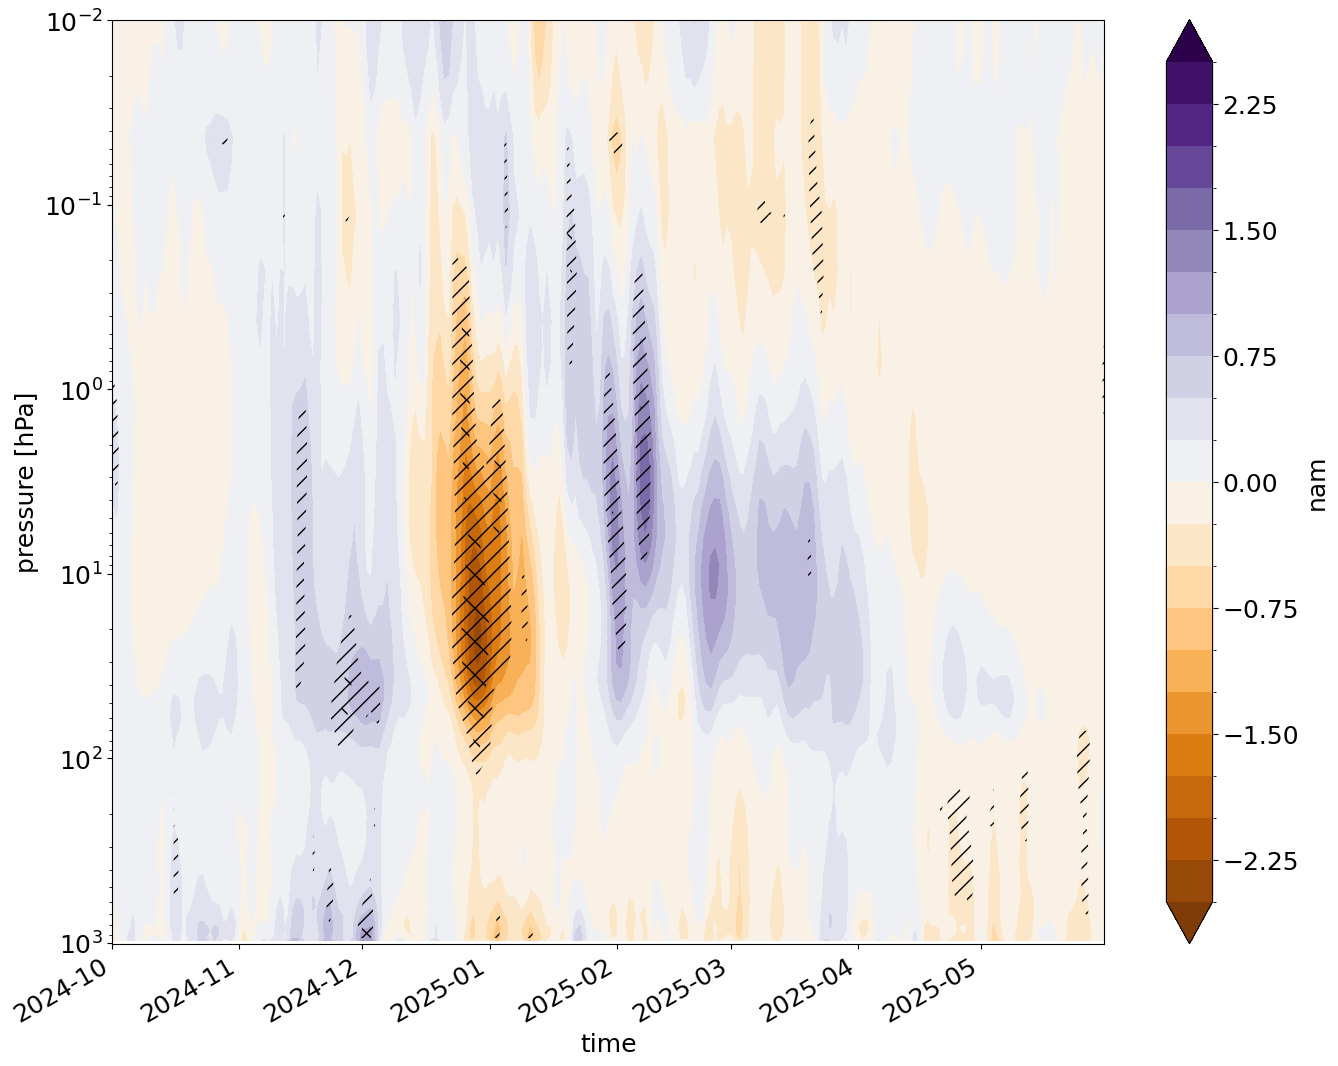

In [273]:
sel_dict = dict(time=slice("2024-10", "2025-05"))

p= diff.sel(**sel_dict).plot.contourf(
    x="time", yincrease=False, levels=21, size=12, vmax = p.colorbar.vmax, extend = 'both', cmap="PuOr"
)

ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.01]
kwargs['hatches'] = ["\\",  None]
diff_pv.sel(**sel_dict).plot.contourf(x="time", ax=ax, **kwargs)

kwargs = dict(
    yincrease= False,
    colors=("k"),
    add_colorbar=False,
    levels=[0, 0.3],
)
diff_pv_fdr.sel(**sel_dict).plot.contour(x="time", ax=ax, **kwargs)

plt.yscale("log")

In [61]:
what = "ta-ua-va"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*2025.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*2025.nc"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_ta-ua-va_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_ta-ua-va_2021-2025.nc')]

In [65]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, ['t','u','v'], deseasonalize=False)
ds_w

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    t        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:15:52 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [64]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, ['t','u','v'], deseasonalize=False)
ds_wo

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    t        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:16:11 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [11]:
weights = np.cos(np.deg2rad(ds_wo.lat))
weights.name = "weights"
weights


NameError: name 'ds_wo' is not defined

In [ ]:
clim

In [67]:
time_slice = slice("2023-09-15", "2024-04")
temp = ds_w.sel(time=time_slice)
ep_diags_w = climate.ComputeEPfluxDivXr(temp["u"], temp["v"], temp["t"], pres="plev")

temp = ds_wo.sel(time=time_slice)
ep_diags_wo = climate.ComputeEPfluxDivXr(temp["u"], temp["v"], temp["t"], pres="plev")

In [81]:
ep_ds_w = xr.merge(ep_diags_w).load()
ep_ds_wo = xr.merge(ep_diags_wo).load()

In [83]:
diff_ep1 = ep_ds_w["ep1"].mean("ens") - ep_ds_wo["ep1"].mean("ens")
diff_ep2 = ep_ds_w["ep2"].mean("ens") - ep_ds_wo["ep2"].mean("ens")

In [84]:
epfd_w = add_div(ep_ds_w)
epfd_wo = add_div(ep_ds_wo)

In [85]:
diff_epfd = epfd_w.mean("ens") - epfd_wo.mean("ens")  # high latitudes
diff_epfd

<xarray.DataArray (time: 229, plev: 47, lat: 96)> Size: 8MB
array([[[-1.65573799e+00, -2.08475643e+00, -1.26195441e+00, ...,
         -2.71248816e-01, -7.89885650e-02,  9.77111210e-02],
        [-2.69924792e+00, -3.14454198e+00, -2.50696524e+00, ...,
         -1.78960222e+00, -2.28426977e+00, -1.80416285e+00],
        [-4.63932153e+00, -7.89736499e+00, -8.19161311e+00, ...,
         -1.84257204e+00, -1.79066322e+00, -1.13505019e+00],
        ...,
        [            nan,             nan,             nan, ...,
         -1.97663843e+00,  1.70727342e+00,  5.44047810e-01],
        [            nan,             nan,             nan, ...,
         -1.02444411e+01, -5.39684448e+00, -6.24076657e+00],
        [            nan,             nan,             nan, ...,
         -1.96853418e+01, -1.59658491e+01, -1.63627103e+01]],

       [[ 1.32241229e-01,  7.74387818e-01,  1.03499347e+00, ...,
          8.90854452e-02, -6.92715777e-03, -5.74223945e-02],
        [ 2.97261747e+00,  1.77184093e+00, -1.25918302e-01, ...,
          1.05049796e-01, -2.81328562e-01, -5.62088437e-01],
        [-1.28247083e+00, -4.11506692e-01,  8.59113495e-01, ...,
         -6.56223995e-01, -8.67023096e-01, -6.12024977e-01],
...
        [            nan,             nan,             nan, ...,
          5.27293451e+00,  4.82339794e+00,  4.51627675e+00],
        [            nan,             nan,             nan, ...,
          2.96646843e+00,  3.11973405e-02,  3.66874424e+00],
        [            nan,             nan,             nan, ...,
         -1.35655727e+00,  6.46110947e-01,  1.33237869e+00]],

       [[ 1.47537473e-01,  8.35167826e-01,  1.55302519e+00, ...,
         -5.85003288e-02, -2.95304469e-02,  5.73970682e-02],
        [ 1.42991010e+00,  2.05328892e+00,  1.44706882e+00, ...,
         -4.46140614e-01, -4.60807066e-01, -4.21256044e-01],
        [-3.03945138e+00, -2.25617671e+00, -7.13663782e-01, ...,
         -1.26539576e+00, -1.46246482e+00, -1.15278940e+00],
        ...,
        [            nan,             nan,             nan, ...,
         -1.83867684e+00,  1.32175070e-01,  4.38406893e+00],
        [            nan,             nan,             nan, ...,
         -1.24206270e+01, -8.02070217e+00,  3.67172650e+00],
        [            nan,             nan,             nan, ...,
         -2.17962989e+01, -1.08781191e+01, -2.44278603e+00]]])
Coordinates:
  * time     (time) datetime64[ns] 2kB 2023-09-15 2023-09-16 ... 2024-04-30
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [98]:
diff_epfd.sel(
    time = slice('2023-10-15','2024-3-30',5),
    lat = slice(0,None),
    plev = slice(0.1,100),
)

<xarray.DataArray (time: 34, plev: 19, lat: 48)> Size: 248kB
array([[[-4.59976075e-01, -4.05323401e-01, -2.31946976e-01, ...,
          7.41484768e+00,  5.20144324e+00,  2.36689662e+00],
        [-5.38363865e-02, -3.36096154e-01, -6.11909193e-01, ...,
          6.43244694e+00,  4.58002547e+00,  2.15287345e+00],
        [-3.04085883e-01,  1.18024765e-01,  2.50688206e-01, ...,
          5.14932889e+00,  4.89376138e+00,  3.74051962e+00],
        ...,
        [-2.69410206e-02, -4.16647381e-02,  1.12458880e-02, ...,
          6.61120968e-01,  6.96182176e-01,  5.29298547e-01],
        [ 9.97072645e-02,  3.42795320e-01,  2.24956478e-01, ...,
          5.93618696e-01,  4.62796876e-01,  2.04535368e-01],
        [ 2.53532931e-01,  3.90048200e-02,  9.32831661e-02, ...,
          5.78706935e-01,  5.23296577e-01,  3.51539462e-01]],

       [[-3.54818648e-01, -6.04613557e-01, -6.73250011e-02, ...,
         -6.96922556e+00, -5.30954674e+00, -2.24160993e+00],
        [ 5.06779430e-01,  5.93290120e-01,  7.02368013e-01, ...,
          6.37863129e-01,  1.56498651e-01, -6.84031067e-01],
        [ 4.68503622e-01,  3.55674843e-01, -2.58431187e-01, ...,
          3.77608185e+00,  1.94531115e+00,  2.53898066e-01],
...
        [ 4.62368880e-02, -1.33438716e-01, -1.95149090e-01, ...,
          2.85645735e+00,  2.91590236e+00,  1.98336515e+00],
        [ 8.45032388e-02,  2.39448737e-01,  4.16949275e-01, ...,
          1.28824417e+00,  1.42806152e+00,  6.20380361e-01],
        [-4.12866782e-01,  6.93176338e-01,  9.83352755e-01, ...,
         -6.11984747e-01, -8.38200321e-02,  9.08329052e-02]],

       [[-1.06146300e+00, -6.77239606e-01, -1.48528463e-01, ...,
          4.42638661e-01,  9.63485136e-02, -1.94178536e-01],
        [ 8.82782702e-01,  3.29275588e-01, -2.18122089e-01, ...,
          2.68831711e-01,  4.17911118e-01,  5.65599797e-01],
        [ 9.45767280e-01,  7.08460098e-01,  8.13598175e-01, ...,
         -5.62220383e-01,  2.19297869e-01,  1.14186829e+00],
        ...,
        [ 2.33590028e-01,  1.85851521e-01,  1.25310446e-02, ...,
          3.06440352e-01,  8.88347068e-01,  9.68192083e-01],
        [ 1.21761731e-01, -8.32632162e-02, -1.78400960e-01, ...,
         -8.24924848e-01, -1.42637544e+00, -1.53021399e+00],
        [ 1.49212861e-01,  5.29068417e-01,  7.63844826e-01, ...,
         -9.87102094e-01, -1.35700595e+00, -9.77614663e-01]]])
Coordinates:
  * time     (time) datetime64[ns] 272B 2023-10-15 2023-10-20 ... 2024-03-28
  * lat      (lat) float64 384B 0.9326 2.798 4.663 6.528 ... 84.86 86.72 88.57
  * plev     (plev) float64 152B 0.1112 0.2315 0.4259 ... 59.64 74.06 91.02
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

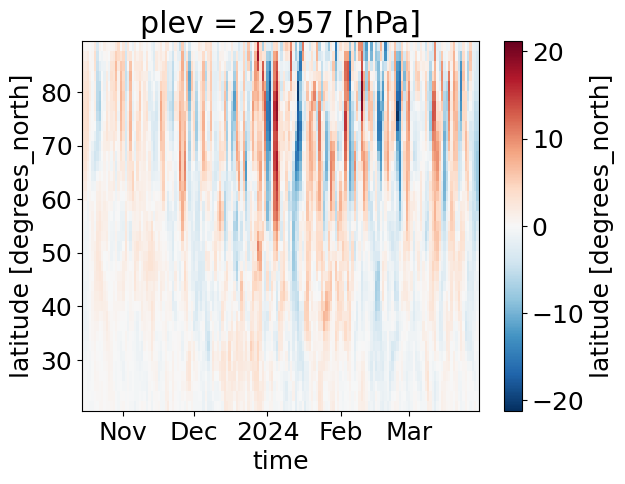

In [104]:
diff_epfd.sel(
    time = slice('2023-10-15','2024-3-30',None),
    lat = slice(20,None),
    plev = 2.957139,
).plot(x = 'time', robust = False)

([<matplotlib.axis.YTick at 0x7f9ffd2c6c90>,
 [])

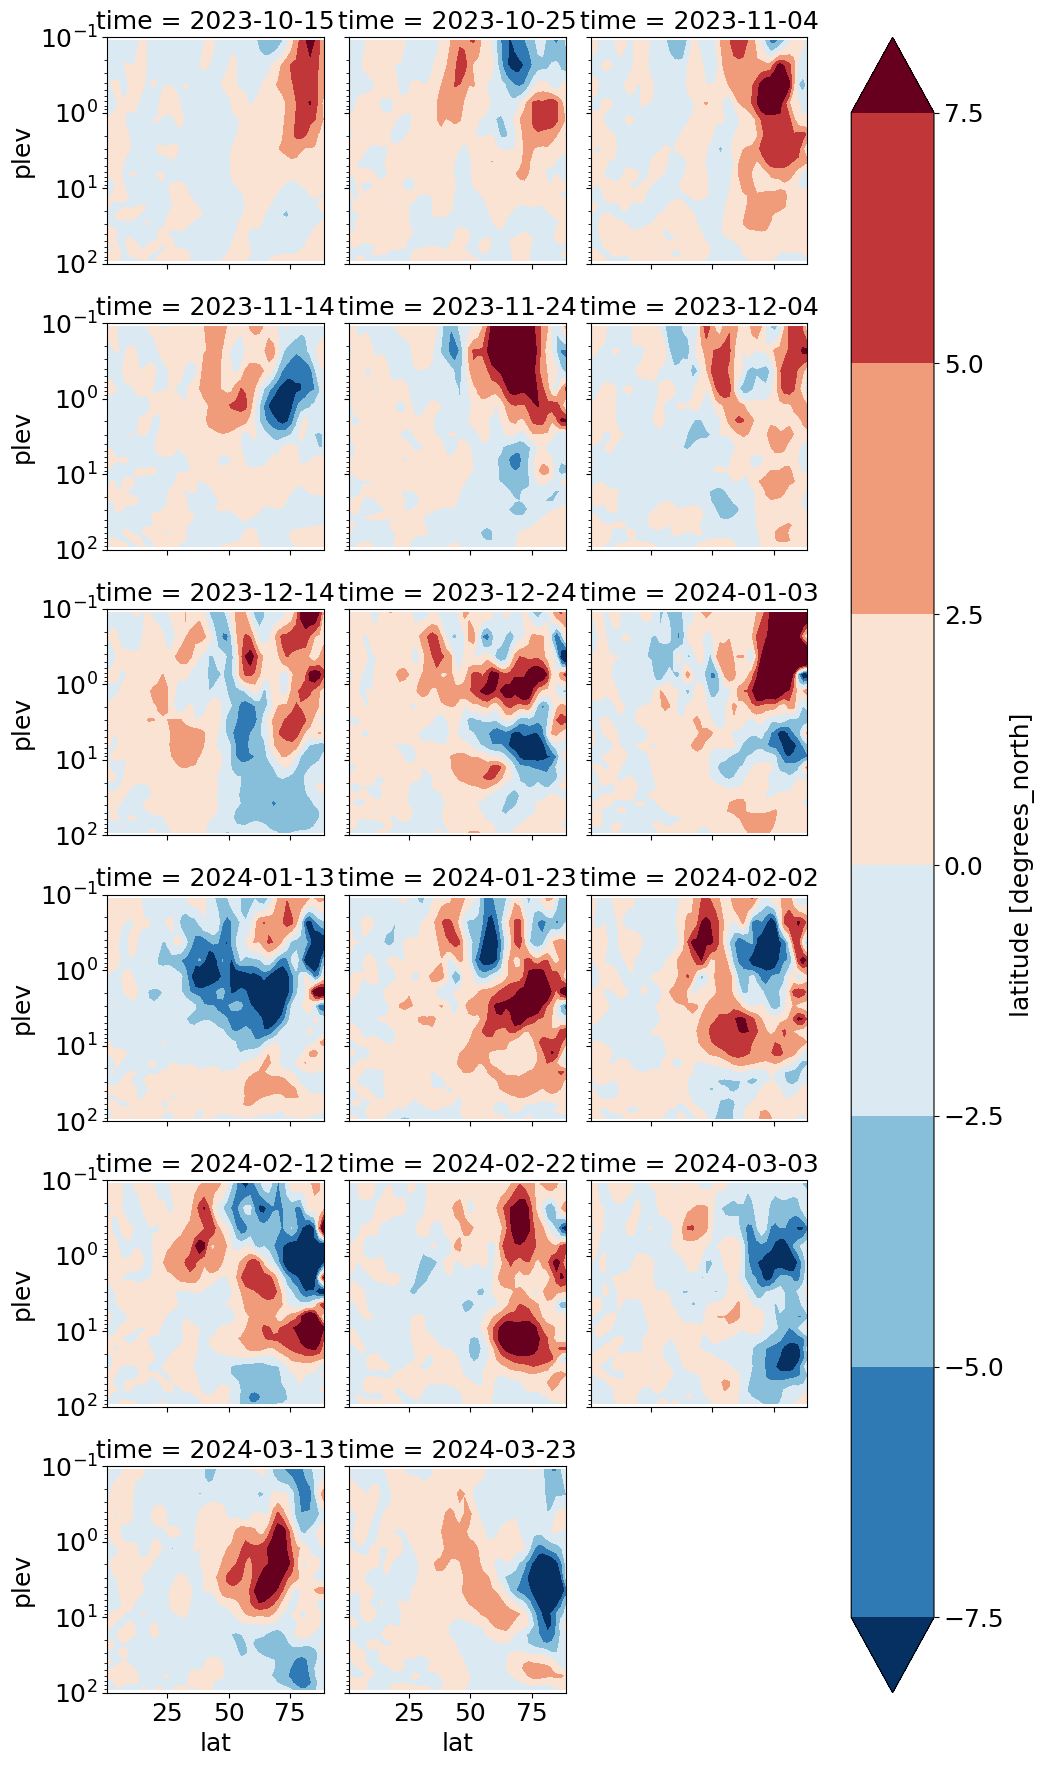

In [99]:
diff_epfd.sel(
    time = slice('2023-10-15','2024-3-30',10),
    lat = slice(0,None),
    plev = slice(0.1,100),
).plot.contourf(col = 'time', yincrease = False, col_wrap = 3, robust = True)
plt.yscale('log')
plt.yticks([100,10,1,0.1])

In [107]:
from cmap import Colormap

cm = Colormap("crameri:broc")  #'crameri:vik')
cmap = cm.to_matplotlib()

In [108]:
diff_u

<xarray.DataArray 'u' (plev: 28, lat: 48)> Size: 5kB
dask.array<sub, shape=(28, 48), dtype=float32, chunksize=(28, 48), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 2023-10-15
  * lat      (lat) float64 384B 0.9326 2.798 4.663 6.528 ... 84.86 86.72 88.57
  * plev     (plev) float64 224B 0.009946 0.04281 0.1112 ... 208.7 238.3 270.1
Attributes:
    long_name:         u-velocity
    units:             m/s
    code:              131
    table:             128
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

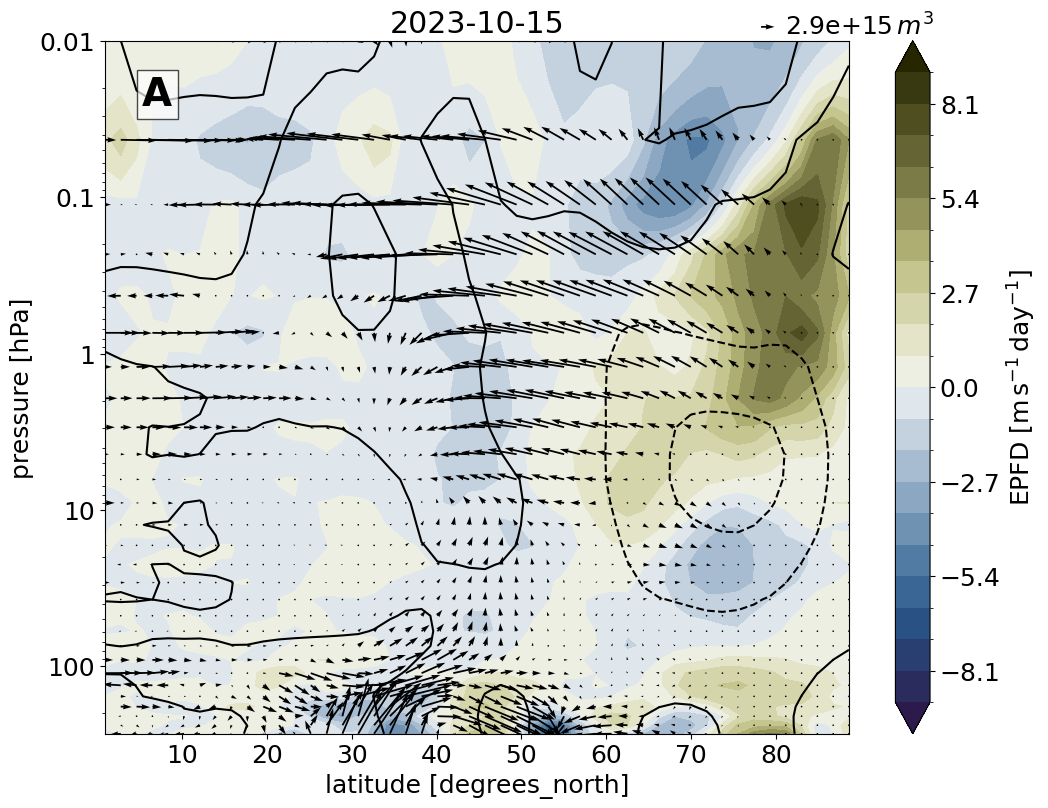

In [109]:
fig, ax = plt.subplots(figsize = (12,9))
i = 15
sel_time = f'2023-10-{i:02d}'
#print(sel_time)
sel_dict = dict(plev = slice(None,300), lat = slice(0,None), time = sel_time)
ep1 = diff_ep1.sel(**sel_dict)
ep2 = diff_ep2.sel(**sel_dict)

lats = ep1.lat
plevs = ep1.plev

diff_u = ds_w['u'].sel(**sel_dict).mean(['ens','lon'])-ds_wo['u'].sel(**sel_dict).mean(['ens','lon'])
diff_u.plot.contour(ax = ax, colors = ('k'))

p = diff_epfd.sel(**sel_dict).plot.contourf(
    yincrease = True, 
    levels = 21, vmax = 9,
    extend = 'both', ax=ax, cmap=cmap, cbar_kwargs = dict(label = 'EPFD [$\mathrm{m\,s^{-1}\,day^{-1}}$]')
)
ax.set_title(sel_time)
#ax.set_yscale('log')
Fphi,Fp = climate.PlotEPfluxArrows(lats,plevs,ep1,ep2,fig,ax,xlim=None,ylim=None,xscale='linear',yscale='log',invert_y=True, newax=False, pivot='tail',scale=None,quiv_args=None)

ax.text(
        0.05,
        0.95,
        ascii_uppercase[0],#f'{sel_var[:-2]} ({label})',
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
fmt = mpl.ticker.FormatStrFormatter("%g")
ax.yaxis.set_major_formatter(fmt)

In [ ]:
cmap = "PuOr_r"
cmap = "RdGy_r"
cm = Colormap("crameri:broc")  #'crameri:vik')
cmap = cm.to_matplotlib()

outpath = "/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/figs/strengthening/"
#for i, label in zip(range(1, 32), all_leters):  # ascii_uppercase
for i in pd.date_range('2023-09-15','2024-10-14', freq = '1D'):
    fig, ax = plt.subplots(figsize=(12, 9))
    #sel_time = f"2023-03-{i:02d}"
    print(i)
    sel_time = i.strftime('%Y-%m-%d')
    sel_dict = dict(plev=slice(None, 300), lat=slice(0, None), time=sel_time)
    ep1 = diff_ep1.sel(**sel_dict)
    ep2 = diff_ep2.sel(**sel_dict)

    lats = ep1.lat
    plevs = ep1.plev

    diff_u = ds_w["u"].sel(**sel_dict).mean(["ens", "lon"]) - ds_wo["u"].sel(
        **sel_dict
    ).mean(["ens", "lon"])
    diff_u.plot.contour(ax=ax, colors=("k"))

    p = diff_epfd.sel(**sel_dict).plot.contourf(
        yincrease=True,
        levels=21,
        vmax=9,
        extend="both",
        ax=ax,
        cmap=cmap,
        cbar_kwargs=dict(label="EPFD [$\mathrm{m\,s^{-1}\,day^{-1}}$]"),
    )
    ax.set_title(sel_time)
    # ax.set_yscale('log')
    Fphi, Fp = climate.PlotEPfluxArrows(
        lats,
        plevs,
        ep1,
        ep2,
        fig,
        ax,
        xlim=None,
        ylim=None,
        xscale="linear",
        yscale="log",
        invert_y=True,
        newax=False,
        pivot="tail",
        scale=None,
        quiv_args=None,
    )
    """
    ax.text(
        0.05,
        0.95,
        label,  # ascii_uppercase[j],#f'{sel_var[:-2]} ({label})',
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    """
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)

    outfile = f"{outpath}EPFD_plot_{sel_time}.pdf"
    print(outfile)
    plt.savefig(outfile, bbox_inches="tight")

In [124]:
!pdftk /sto0/data/Intermediate/Hunga_Tonga_byAles/ht/figs/strengthening/EPFD_plot_202?-*.pdf output EPFD_plot_2023-2024.pdf

In [10]:
time_slice = slice("2024-02-01", "2024-02-28")
sel_dict = dict(time=time_slice)
sel_var = 't'

ds_w_sel = ds_w[sel_var].sel(**sel_dict).load()

In [11]:
ds_wo_sel = ds_wo[sel_var].sel(**sel_dict).load()

In [12]:
diff = ds_w_sel.mean(["ens",'lon','time']) - ds_wo_sel.mean(["ens",'lon','time'])
diff

<xarray.DataArray 't' (plev: 47, lat: 96)>
array([[-0.65856934, -0.61920166, -0.6432648 , ..., -1.3951721 ,
        -1.3479004 , -1.2332001 ],
       [-1.1030731 , -1.1056519 , -1.0329132 , ..., -1.1219482 ,
        -1.1663818 , -1.2214966 ],
       [-1.0141907 , -0.97372437, -0.9575958 , ...,  1.9771271 ,
         2.0829163 ,  2.1250916 ],
       ...,
       [        nan,         nan,         nan, ..., -0.72232056,
        -0.6227417 , -0.66999817],
       [        nan,         nan,         nan, ..., -0.66963196,
        -0.77005005, -1.0242615 ],
       [        nan,         nan,         nan, ..., -0.18206787,
        -0.5864258 , -1.1265717 ]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -88.57 -86.72 -84.86 -83.0 ... 83.0 84.86 86.72 88.57
  * plev     (plev) float64 0.009946 0.04281 0.1112 ... 971.4 995.4 1.009e+03
Attributes:
    code:              130
    table:             128
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

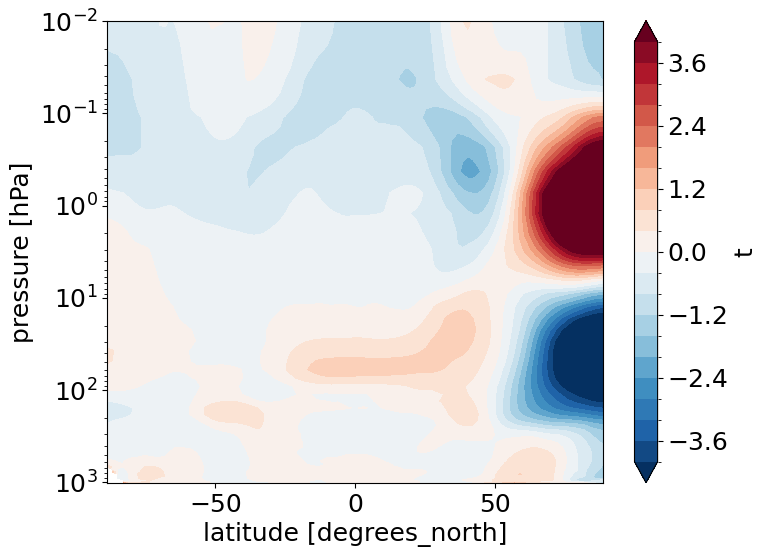

In [14]:
diff.plot.contourf(yincrease = False, robust = True, size = 6, levels = 21)
plt.yscale('log')

## Age of air

In [5]:
what = "AoA_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*"))

In [6]:
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_AoA_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_AoA_mm_zon_2021-2025.nc')]

In [6]:
ds_w_aoa = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit = 0.1)
    .load()
)
ds_w_aoa

<xarray.Dataset> Size: 6MB
Dimensions:   (ens: 10, time: 60, plev: 26, lat: 96, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev      (plev) float64 208B 0.1112 0.2315 0.4259 ... 208.7 238.3 270.1
  * lat       (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon       (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    IdealAge  (ens, time, plev, lat, lon) float32 6MB 1.468e+03 ... 123.3
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Sun Mar 31 19:12:51 2024: cdo cat Postproc_example-AoA-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [7]:
ds_wo_aoa = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit = 0.1)
    .load()
)
ds_wo_aoa

<xarray.Dataset> Size: 6MB
Dimensions:   (ens: 10, time: 60, plev: 26, lat: 96, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev      (plev) float64 208B 0.1112 0.2315 0.4259 ... 208.7 238.3 270.1
  * lat       (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon       (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    IdealAge  (ens, time, plev, lat, lon) float32 6MB 1.503e+03 ... 148.4
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Sun Mar 31 19:12:51 2024: cdo cat Postproc_example-AoA-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [8]:
weights = np.cos(np.deg2rad(ds_wo_aoa.lat))
weights.name = "weights"
weights


<xarray.DataArray 'weights' (lat: 96)> Size: 768B
array([0.02491778, 0.05717144, 0.08955539, 0.12188768, 0.15410725,
       0.1861715 , 0.21804295, 0.24968611, 0.28106651, 0.31215034,
       0.34290431, 0.37329559, 0.40329182, 0.43286109, 0.46197199,
       0.49059359, 0.51869553, 0.54624798, 0.57322171, 0.59958812,
       0.62531924, 0.65038779, 0.6747672 , 0.6984316 , 0.72135592,
       0.74351585, 0.76488791, 0.78544943, 0.80517862, 0.82405458,
       0.84205728, 0.85916766, 0.87536757, 0.89063985, 0.9049683 ,
       0.91833775, 0.93073401, 0.94214396, 0.9525555 , 0.96195759,
       0.97034027, 0.97769466, 0.98401296, 0.98928847, 0.9935156 ,
       0.99668988, 0.99880794, 0.99986753, 0.99986753, 0.99880794,
       0.99668988, 0.9935156 , 0.98928847, 0.98401296, 0.97769466,
       0.97034027, 0.96195759, 0.9525555 , 0.94214396, 0.93073401,
       0.91833775, 0.9049683 , 0.89063985, 0.87536757, 0.85916766,
       0.84205728, 0.82405458, 0.80517862, 0.78544943, 0.76488791,
       0.74351585, 0.72135592, 0.6984316 , 0.6747672 , 0.65038779,
       0.62531924, 0.59958812, 0.57322171, 0.54624798, 0.51869553,
       0.49059359, 0.46197199, 0.43286109, 0.40329182, 0.37329559,
       0.34290431, 0.31215034, 0.28106651, 0.24968611, 0.21804295,
       0.1861715 , 0.15410725, 0.12188768, 0.08955539, 0.05717144,
       0.02491778])
Coordinates:
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

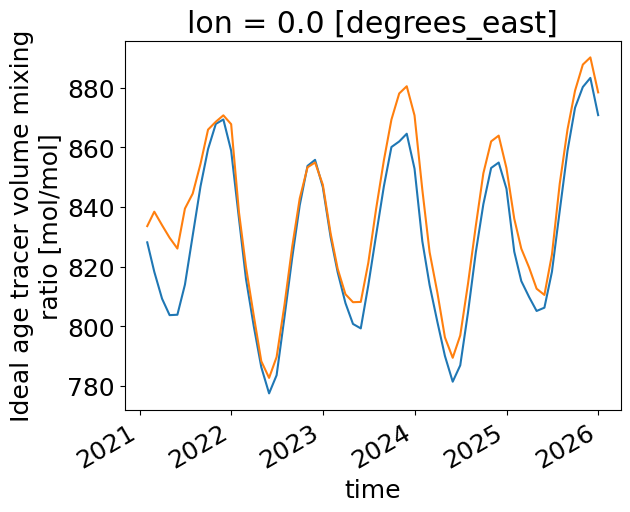

In [210]:
sel_var = 'IdealAge'
ds_w_aoa[sel_var].sel(plev = slice(30,70)).weighted(weights).mean(['lat','plev','ens']).plot()
ds_wo_aoa[sel_var].sel(plev = slice(30,70)).weighted(weights).mean(['lat','plev','ens']).plot()

Text(0.5, 1.0, 'globally lower stratosphere')

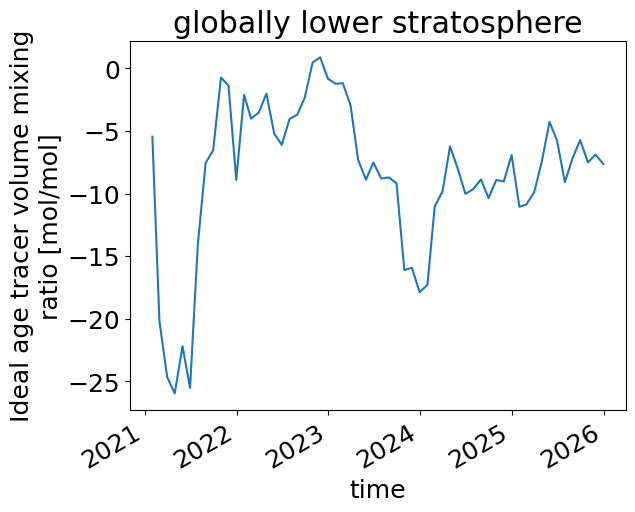

In [218]:
sel_var = 'IdealAge'
sel_dict = dict(plev = slice(30,70))

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens'])
diff.plot()
plt.title('globally lower stratosphere')

Text(0.5, 1.0, 'globally uppwer stratosphere')

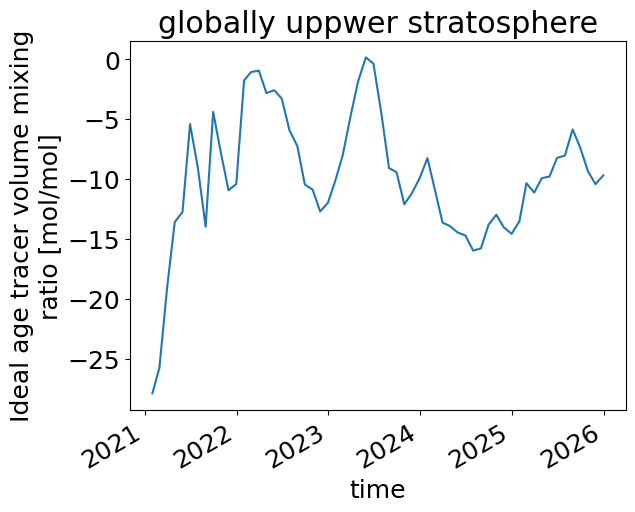

In [219]:
sel_var = 'IdealAge'
sel_dict = dict(plev = slice(1,5))

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens'])
diff.plot()
plt.title('globally uppwer stratosphere')

Text(0.5, 1.0, 'polar uppwer stratosphere')

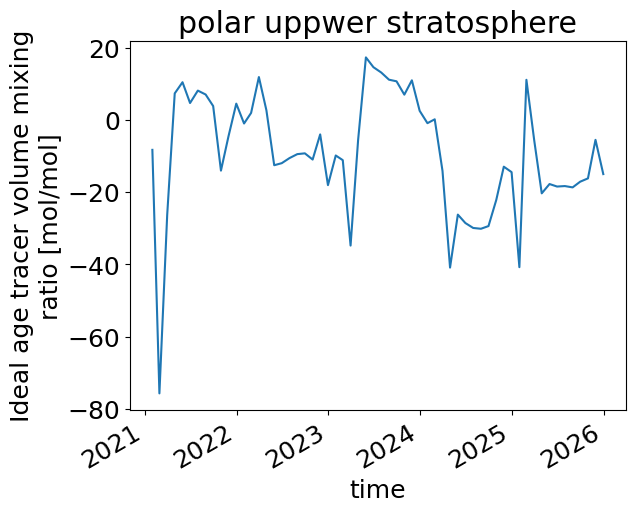

In [243]:
sel_var = 'IdealAge'
sel_dict = dict(plev = slice(1,5), lat = slice(None,60))

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens'])
diff.plot()
plt.title('polar uppwer stratosphere')

Text(0.5, 1.0, 'polar lower stratosphere')

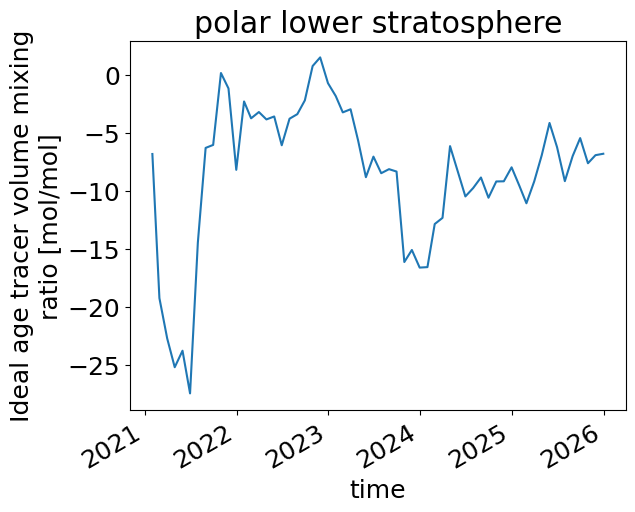

In [223]:
sel_var = 'IdealAge'
sel_dict = dict(plev = slice(30,70), lat = slice(60,None))

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','plev','ens'])
diff.plot()
plt.title('polar lower stratosphere')

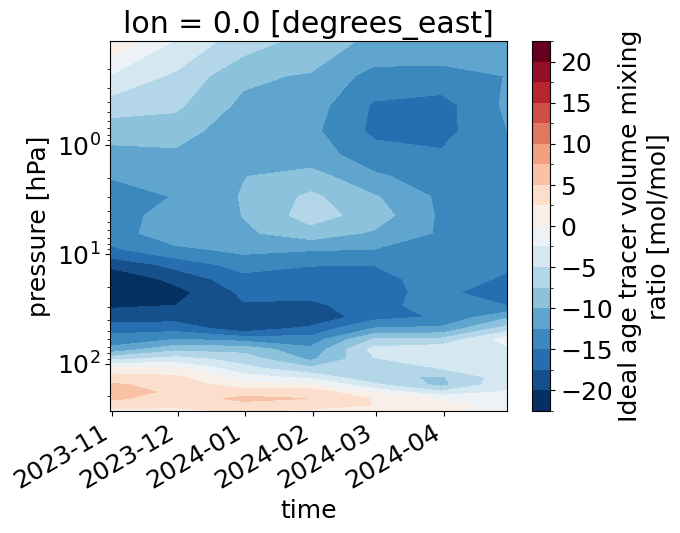

In [230]:
sel_var = 'IdealAge'
sel_dict = dict(time = slice('2023-10', '2024-04'), lat = slice(70,None))

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat','ens'])
diff.squeeze().plot.contourf(x = 'time', robust = True, yincrease = False, levels = 21)
plt.yscale('log')
#plt.title('polar uppwer stratosphere')

/tmp/ipykernel_3749664/1466662373.py:12: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


AoA-evolution_2023-2024.pdf


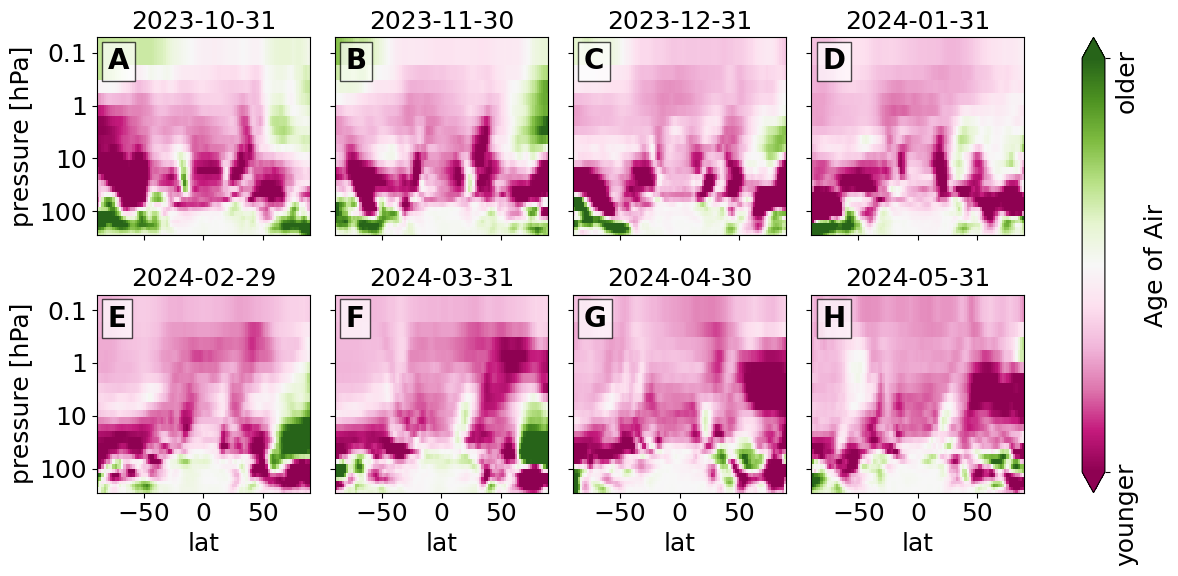

In [25]:
sel_var = 'IdealAge'
sel_dict = dict(time = slice('2023-10', '2024-05'))

vmax = 28
diff = ds_w_aoa[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).mean(['ens'])
p = diff.plot(col = 'time', robust = True, yincrease = False, col_wrap = 4, vmax = vmax, cmap="PiYG", cbar_kwargs=dict(ticks=[-vmax, vmax], label="Age of Air"))

p.cbar.ax.set_yticklabels(["younger", "older"])
p.cbar.ax.yaxis.set_tick_params(rotation=90)
p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')
#plt.title('polar uppwer stratosphere')
outfile = f"AoA-evolution_2023-2024.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

/tmp/ipykernel_3749664/2806330057.py:12: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


AoA-evolution_2023-2024.pdf


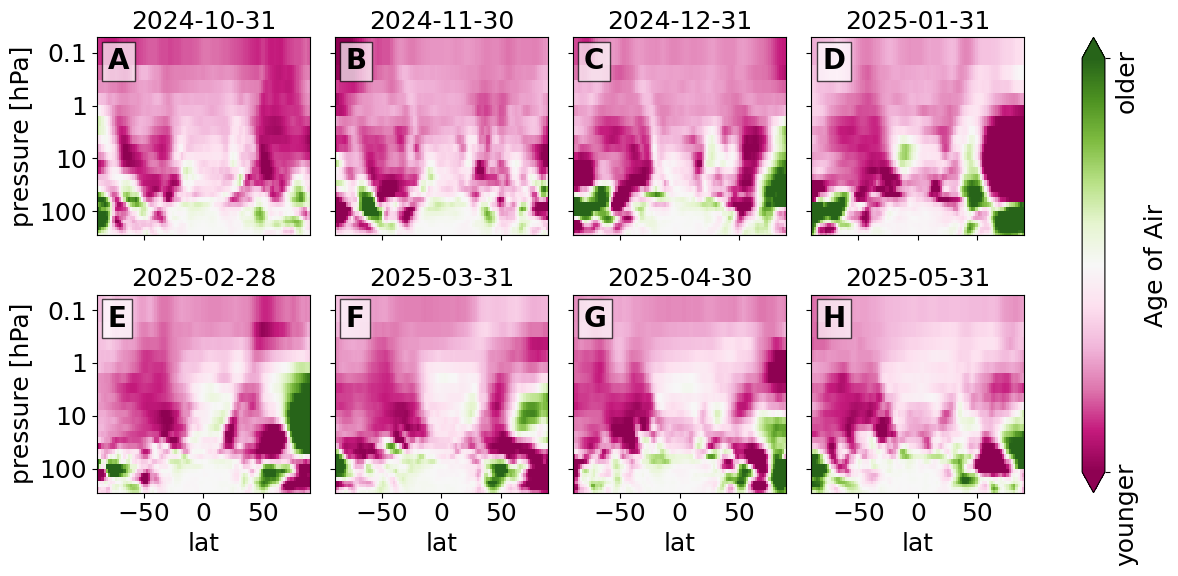

In [26]:
sel_var = 'IdealAge'
sel_dict = dict(time = slice('2024-10', '2025-05'))

vmax = 28
diff = ds_w_aoa[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).mean(['ens'])
p = diff.plot(col = 'time', robust = True, yincrease = False, col_wrap = 4, vmax = vmax, cmap="PiYG", cbar_kwargs=dict(ticks=[-vmax, vmax], label="Age of Air"))

p.cbar.ax.set_yticklabels(["younger", "older"])
p.cbar.ax.yaxis.set_tick_params(rotation=90)
p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')
#plt.title('polar uppwer stratosphere')
outfile = f"AoA-evolution_2023-2024.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

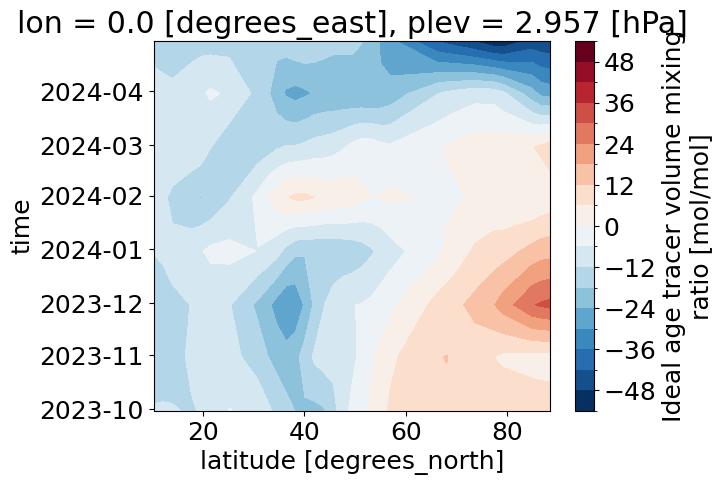

In [242]:
sel_var = 'IdealAge'
sel_dict = dict(time = slice('2023-09', '2024-04'), lat = slice(None,10), plev = 2.957139)

diff = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['ens']) - ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['ens'])
diff.squeeze().plot.contourf(y = 'time', yincrease = True, levels = 21)
#plt.yscale('log')
#plt.title('polar uppwer stratosphere')

In [40]:
ds_w_chem

<xarray.Dataset> Size: 19MB
Dimensions:  (ens: 10, time: 60, plev: 21, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.04281 0.1112 0.2315 ... 74.06 91.02 110.7
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 5MB 236.8 236.3 ... 224.4 224.5
    u_m      (ens, time, plev, lat, lon) float32 5MB -1.594 -1.359 ... 0.02829
    O3_m     (ens, time, plev, lat, lon) float32 5MB 1.577e-06 ... 7.908e-07
    H2O_m    (ens, time, plev, lat, lon) float32 5MB 2.381e-06 ... 3.57e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Mar 12 10:25:13 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

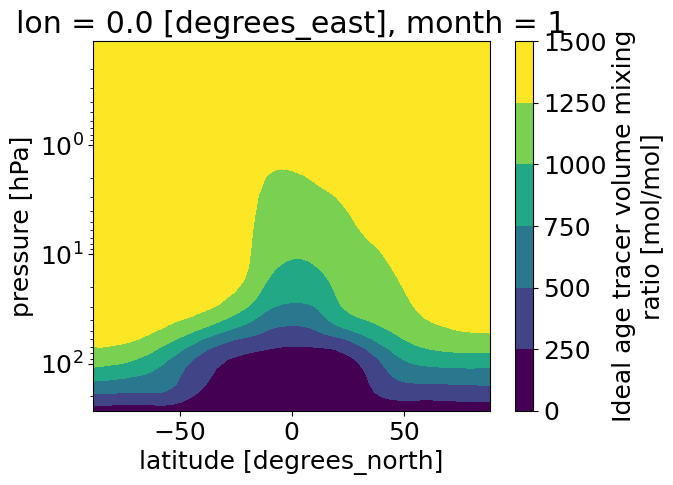

In [69]:
clim = ds_w_aoa['IdealAge'].groupby('time.month').mean('time').mean('ens').squeeze()
clim.sel(month = 1).plot.contourf(yincrease = False, x = 'lat')
plt.yscale('log')

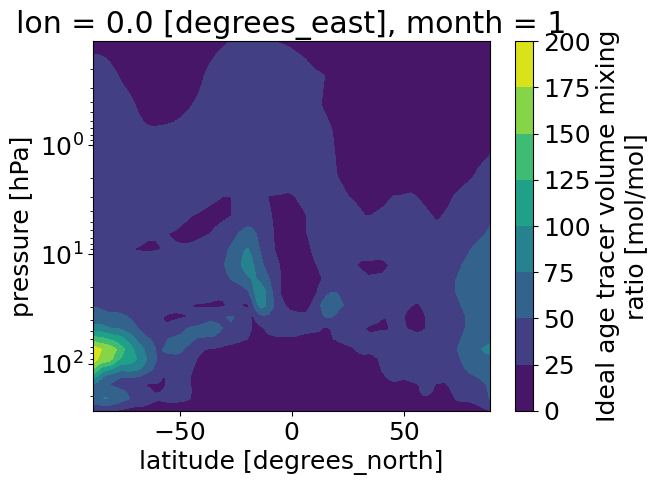

In [10]:
clim_std_wo = ds_wo_aoa['IdealAge'].groupby('time.month').std('time').mean('ens').squeeze()
clim_std_wo.sel(month = 1).plot.contourf(yincrease = False, x = 'lat')
plt.yscale('log')

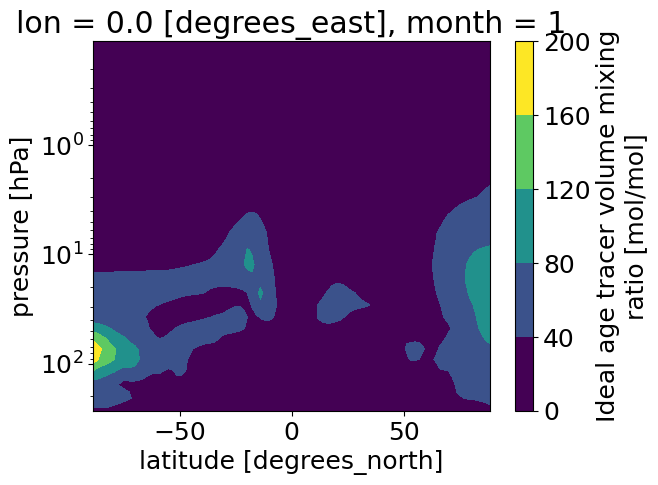

In [72]:
clim_std_w = ds_w_aoa['IdealAge'].groupby('time.month').std('time').mean('ens').squeeze()
clim_std_w.sel(month = 1).plot.contourf(yincrease = False, x = 'lat')
plt.yscale('log')

In [78]:
clim_std_wo.sel(lat = slice(None,60), plev = slice(0.1,200)).weighted(weights).mean('lat')

<xarray.DataArray 'IdealAge' (month: 12, plev: 23)> Size: 2kB
array([[16.51476047, 16.6258327 , 17.44354318, 18.60831887, 19.96950612,
        21.66518269, 24.33376106, 28.37871189, 31.94039016, 34.50681008,
        38.9206385 , 42.29414022, 43.54130461, 41.43988907, 39.14606102,
        38.35237129, 42.33438518, 49.03916009, 46.27151775, 38.28050384,
        32.35992607, 29.56167201, 27.98393665],
       [20.72591146, 23.52016533, 26.58499006, 27.32530127, 26.69574818,
        27.28719004, 28.98833405, 30.97377882, 33.555652  , 39.02222615,
        43.26086567, 45.32006236, 47.75503492, 51.31464976, 52.16803552,
        53.1093282 , 58.92091677, 61.31906844, 57.32067234, 49.24602801,
        40.8052392 , 38.67988439, 40.27049796],
       [27.22530681, 24.8827427 , 23.72277077, 25.46244234, 26.10639877,
        28.39469947, 30.26339385, 31.56272585, 31.92944812, 33.28045616,
        36.59613566, 39.2974173 , 42.41009501, 50.02249951, 53.80234569,
        51.84296086, 48.71984611, 45.72026391, 42.2687096 , 34.03194876,
        33.28141159, 39.40886959, 46.08289402],
       [27.75035777, 27.23521106, 29.32716806, 30.21065829, 28.54248781,
        29.10666642, 29.38208041, 28.55197872, 29.03546443, 31.23974326,
        34.8301899 , 36.00453619, 37.47175862, 44.92757908, 55.59217646,
        61.8052333 , 60.79033539, 55.79338478, 52.74798488, 46.28597926,
        38.32058669, 36.05566766, 41.90500221],
...
       [19.85623103, 19.92171654, 19.65682549, 19.73274317, 20.30615017,
        21.35568701, 22.66074639, 24.34745963, 26.65641761, 29.54582677,
        30.95212033, 28.63296546, 23.34696485, 24.42253905, 35.51018095,
        42.84902372, 38.06806778, 27.89842121, 22.17605042, 20.64706798,
        20.98193744, 21.61165529, 21.25630486],
       [18.58007396, 20.40275695, 21.83759601, 21.87500929, 21.35075223,
        21.88705851, 23.03329145, 24.18047639, 25.72172225, 27.51017063,
        28.05746884, 25.9148701 , 24.13350323, 26.97751993, 35.98584946,
        42.13441696, 40.22534738, 32.76229258, 25.44632677, 18.9447921 ,
        17.67246718, 18.5540928 , 18.00069901],
       [22.2789443 , 22.4754267 , 22.16842769, 21.63250437, 21.62966079,
        23.32558025, 27.14075146, 29.51360058, 29.28934512, 28.48396013,
        27.52921702, 25.20078462, 25.83446125, 31.97700337, 39.87755255,
        46.02121068, 45.41699351, 41.65822482, 38.25873338, 33.38267598,
        26.02116826, 22.80776307, 20.74969794],
       [17.35970487, 16.5598512 , 17.67380864, 19.18473245, 19.05387083,
        18.78599054, 21.79648153, 28.04425457, 36.32244334, 40.81308486,
        41.31395034, 39.48196057, 38.94998794, 38.94580964, 43.02602589,
        49.34818558, 53.78405919, 52.28676988, 46.65693498, 37.85156598,
        28.58877464, 23.89347657, 24.41093445]])
Coordinates:
  * plev     (plev) float64 184B 0.1112 0.2315 0.4259 ... 132.4 155.8 181.2
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      (month) float64 96B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Attributes:
    long_name:         Ideal age tracer volume mixing ratio
    units:             mol/mol
    code:              130
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [74]:
 (arr1.mean('ens') - arr2.mean('ens'))

<xarray.DataArray 'IdealAge' (time: 9, plev: 23)> Size: 2kB
array([[ 12.90479366,  13.19804014,  13.35648084,  13.78612787,
         14.05080264,  12.9781252 ,  11.08223557,   6.20718215,
          0.47438835,  -6.39777856, -10.00242521, -12.81967571,
        -16.50517698, -23.15164433, -31.4405162 , -25.61422073,
        -11.04796643,  -2.12428825,   7.16673427,  20.05887946,
         25.94100886,  24.18120916,  14.09514673],
       [  9.78140156,   9.60687378,   9.87133708,  10.42512739,
         11.13110808,  11.79414167,  10.76681346,   6.85430449,
          1.46277418,  -5.84177534, -10.90562658, -13.94366697,
        -16.78940727, -21.40807419, -25.92770704, -28.9794921 ,
        -20.06183603, -13.8490705 ,  -9.21533958,   2.33339453,
         18.38246297,  28.95375811,  23.34751007],
       [  4.40232419,   2.57483641,   1.67077989,   2.6633903 ,
          4.68580782,   7.57897784,   9.24369767,   6.87402668,
          1.17328537,  -5.56248484, -11.44261535, -15.98659988,
        -17.73765461, -17.98339101, -18.18962262, -20.0771337 ,
        -16.08827942,  -8.09475207,  -1.39489964,   4.65681245,
         12.693288  ,  19.09165517,  26.45730603],
       [ -0.88153101,   0.95954963,   4.68897098,   6.86116351,
          6.72787111,   8.84788362,  11.3075934 ,  10.22978596,
...
        -40.99893867, -40.58798911, -35.50473406, -22.31469667,
         -8.1743481 ,  -2.59780401,  -0.85820978],
       [ -8.3623393 ,  -7.50233551,  -9.39223092,  -9.46192745,
         -6.19939557,  -3.05399507,   0.63337004,   3.54672811,
          4.15584116,   5.06229081,  10.28888931,  22.30374627,
         33.20366147,  35.39587803,  32.46292058,  28.70227903,
         18.81878505,   1.76790946, -14.1257645 , -22.47085785,
        -30.1394205 , -31.65994513, -30.70027638],
       [ -8.4727183 , -13.69958405, -22.39723348, -27.30324964,
        -24.70113256, -19.03047618, -12.83519252,  -5.9554595 ,
          1.25352484,   2.70447217,   4.22157283,   8.81688958,
         16.23600369,  25.35360014,  29.6808141 ,  32.88570279,
         26.70781108,  10.54555102,  -5.24022457, -21.64878383,
        -37.98425702, -41.60322851, -42.2977582 ],
       [ -9.03064966,  -5.84931091, -12.50339573, -23.16161923,
        -31.84104802, -39.05914497, -44.00312356, -41.31567548,
        -30.63004114, -19.04093325, -12.35575914, -12.12638254,
        -14.32353403, -15.31747186, -12.26621904,  -3.10835626,
          2.89058705,  -0.90141578,  -9.02234769, -22.10559283,
        -28.06371587, -26.21963166, -17.63867914]])
Coordinates:
  * time     (time) datetime64[ns] 72B 2023-08-31 2023-09-30 ... 2024-04-30
    lon      float64 8B 0.0
  * plev     (plev) float64 184B 0.1112 0.2315 0.4259 ... 132.4 155.8 181.2
Attributes:
    long_name:         Ideal age tracer volume mixing ratio
    units:             mol/mol
    code:              130
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

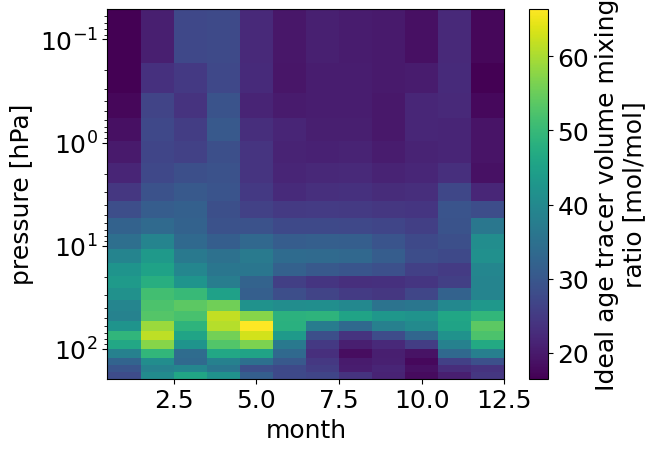

In [84]:
clim_std_wo_polar.plot(x = 'month', yincrease=False)
plt.yscale('log')

AoA_evolution_2023-2024.pdf


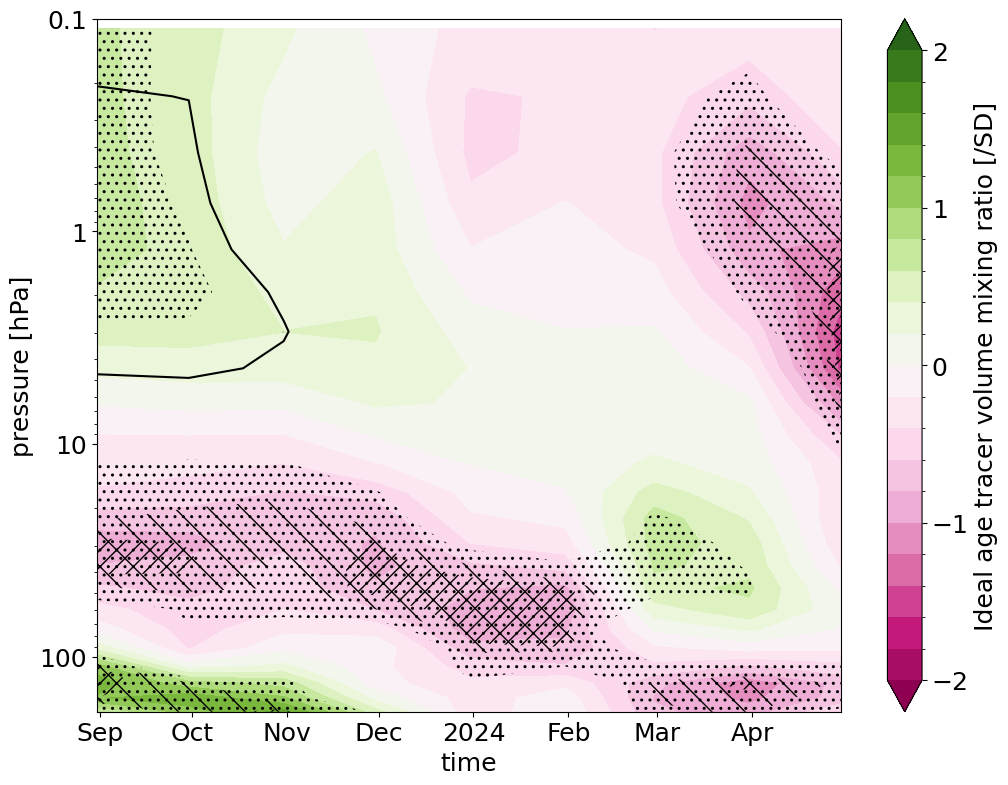

In [16]:
sel_var = 'IdealAge'
sel_dict = dict(time = slice('2023-08', '2024-04'), lat = slice(None,60), plev = slice(0.1,200))
arr1 = ds_w_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat']).squeeze()
arr2 = ds_wo_aoa[sel_var].sel(**sel_dict).weighted(weights).mean(['lat']).squeeze()
#diff = arr1.mean('ens') - arr2.mean('ens')
clim_std_wo_polar = clim_std_wo.sel(lat = slice(None,60), plev = slice(0.1,200)).weighted(weights).mean('lat')
diff = (arr1.mean('ens') - arr2.mean('ens')).groupby('time.month')/clim_std_wo_polar
_, p_values = stats.ttest_ind(arr1, arr2, equal_var=False)
diff_pv = xr.DataArray(p_values, coords=diff.coords)
diff_pv_fdr = xr_multipletest(diff_pv)[1]

# plot
# age of air
p = diff.plot.contourf(x = 'time', yincrease = False, extend = 'both', cmap="PiYG", levels = np.arange(-2,2.2,0.2), size = 9)
ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    # linewidths=np.linspace(1, 4, 4),
)
diff_pv.plot.contourf(x="time", ax=ax, **kwargs)
kwargs['levels'] = [0,0.3]
kwargs['hatches'] = ["..",  None]
diff_pv.plot.contourf(x="time", ax=ax, **kwargs)


kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_pv.plot.contourf(x="time", ax=ax, **kwargs)
# water vapour
sel_var = 'H2O_m'
sel_dict = dict(time = slice('2023-08', '2024-04'), lat = slice(None,60), plev = slice(0.1,200))
arr1 = ds_w_chem[sel_var].sel(**sel_dict).weighted(weights).mean(['lat']).squeeze()
arr2 = ds_wo_chem[sel_var].sel(**sel_dict).weighted(weights).mean(['lat']).squeeze()
diff = (arr1.mean('ens') - arr2.mean('ens'))*1e6
diff.plot.contour(x = 'time', yincrease = False, robust=True, levels = [1], ax = ax, colors = 'k')

ax.set_yscale('log')
ax.set_yticks([100,10,1,0.1])
fmt = mpl.ticker.FormatStrFormatter("%g")
ax.yaxis.set_major_formatter(fmt)
ax.set_title('')

p.colorbar.set_label('Ideal age tracer volume mixing ratio [/SD]')
p.colorbar.set_ticks([-2,-1,0,1,2])
outfile = f"AoA_evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [17]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")


True

In [21]:
#client.ls("Photos", detail=False)
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

In [92]:
client.exists(f"HT_analysis/figs/strengthening/{outfile}")


True

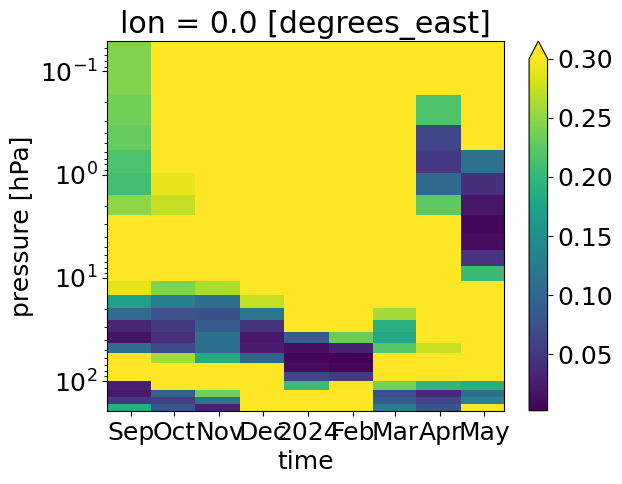

In [54]:
diff_pv.plot(yincrease = False, x = 'time', vmax = 0.3)
plt.yscale('log')

## Chemistry + dynamics

In [6]:
what = "chem_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*"))

In [32]:
infiles_wo

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt28_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt29_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt24_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt25_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt27_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt26_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt23_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt22_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt20_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt21_chem_mm_zon_2021-2025.nc')]

In [15]:
ds_wo_chem = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 320)
    .load()
)
ds_wo_chem

/tmp/ipykernel_712830/2417172904.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  xr.open_mfdataset(
/tmp/ipykernel_712830/2816948166.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


<xarray.Dataset> Size: 26MB
Dimensions:  (ens: 10, time: 60, plev: 28, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev     (plev) float64 224B 0.04281 0.1112 0.2315 ... 238.3 270.1 304.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 6MB nan nan nan ... 211.6 211.7
    u_m      (ens, time, plev, lat, lon) float32 6MB nan nan nan ... 5.24 3.821
    O3_m     (ens, time, plev, lat, lon) float32 6MB nan nan ... 5.739e-08
    H2O_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 2.668e-05
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Thu Feb 29 16:07:22 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [14]:
ds_w_chem = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 320)
    .load()
)
ds_w_chem

/tmp/ipykernel_712830/2816948166.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


<xarray.Dataset> Size: 26MB
Dimensions:  (ens: 10, time: 60, plev: 28, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev     (plev) float64 224B 0.04281 0.1112 0.2315 ... 238.3 270.1 304.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 6MB 236.8 236.3 ... 214.9 215.3
    u_m      (ens, time, plev, lat, lon) float32 6MB -1.594 -1.359 ... -1.376
    O3_m     (ens, time, plev, lat, lon) float32 6MB 1.577e-06 ... 6.75e-08
    H2O_m    (ens, time, plev, lat, lon) float32 6MB 2.381e-06 ... 3.972e-05
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Mar 12 10:25:13 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [10]:
def average(da, sel_dict = dict(plev = slice(125,225), lat = slice(90,50))):
    return da.sel(**sel_dict).weighted(weights).mean(['lon','plev','ens', 'lat'])

def to_monthly(ds):
    year = ds.time.dt.year
    month = ds.time.dt.month

    # assign new coords
    ds = ds.assign_coords(year=("time", year.data), month=("time", month.data))

    # reshape the array to (..., "month", "year")
    return ds.set_index(time=("year", "month")).unstack("time") 

In [13]:
wv_lms_w

<xarray.DataArray 'H2O_m' (time: 60)> Size: 480B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
Attributes:
    long_name:         H2O volume mixing ratio
    units:             mol/mol
    code:              35
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [16]:
weights = np.cos(np.deg2rad(ds_w_chem.lat))
wv_lms_w = average(ds_w_chem['H2O_m']).load()
wv_lms_wo = average(ds_wo_chem['H2O_m']).load()

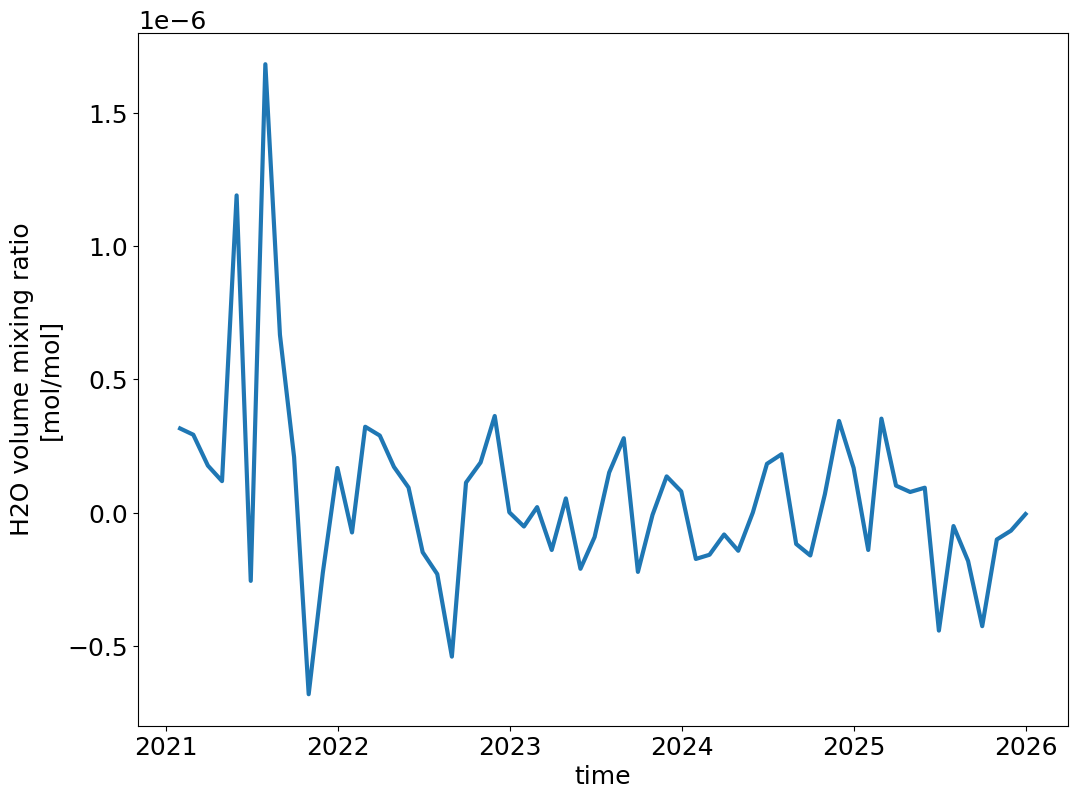

In [18]:
diff = wv_lms_w-wv_lms_wo
diff.plot(size = 9, lw  =3)

In [20]:
from xarray.groupers import SeasonResampler 
da = diff.resample(time=SeasonResampler(["DJF","MAM","JJA",'SON'])).mean()
da#.plot(size = 8)

<xarray.DataArray 'H2O_m' (time: 19)> Size: 152B
array([ 4.95295419e-07,  6.98090313e-07, -2.32371220e-07,  1.38811632e-07,
        1.85363113e-07, -3.06031677e-07,  2.21545109e-07, -9.70402656e-09,
       -9.87529228e-08,  1.13080112e-07, -3.11815211e-08, -8.36998924e-08,
       -7.44279259e-08,  9.53017956e-08,  8.46613882e-08,  1.27127730e-07,
        9.11186802e-08, -2.24385650e-07, -1.97759393e-07])
Coordinates:
  * time     (time) datetime64[ns] 152B 2021-03-01 2021-06-01 ... 2025-09-01
Attributes:
    long_name:         H2O volume mixing ratio
    units:             mol/mol
    code:              35
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [21]:
da.to_netcdf('SOCOL_LMS-ts.nc')

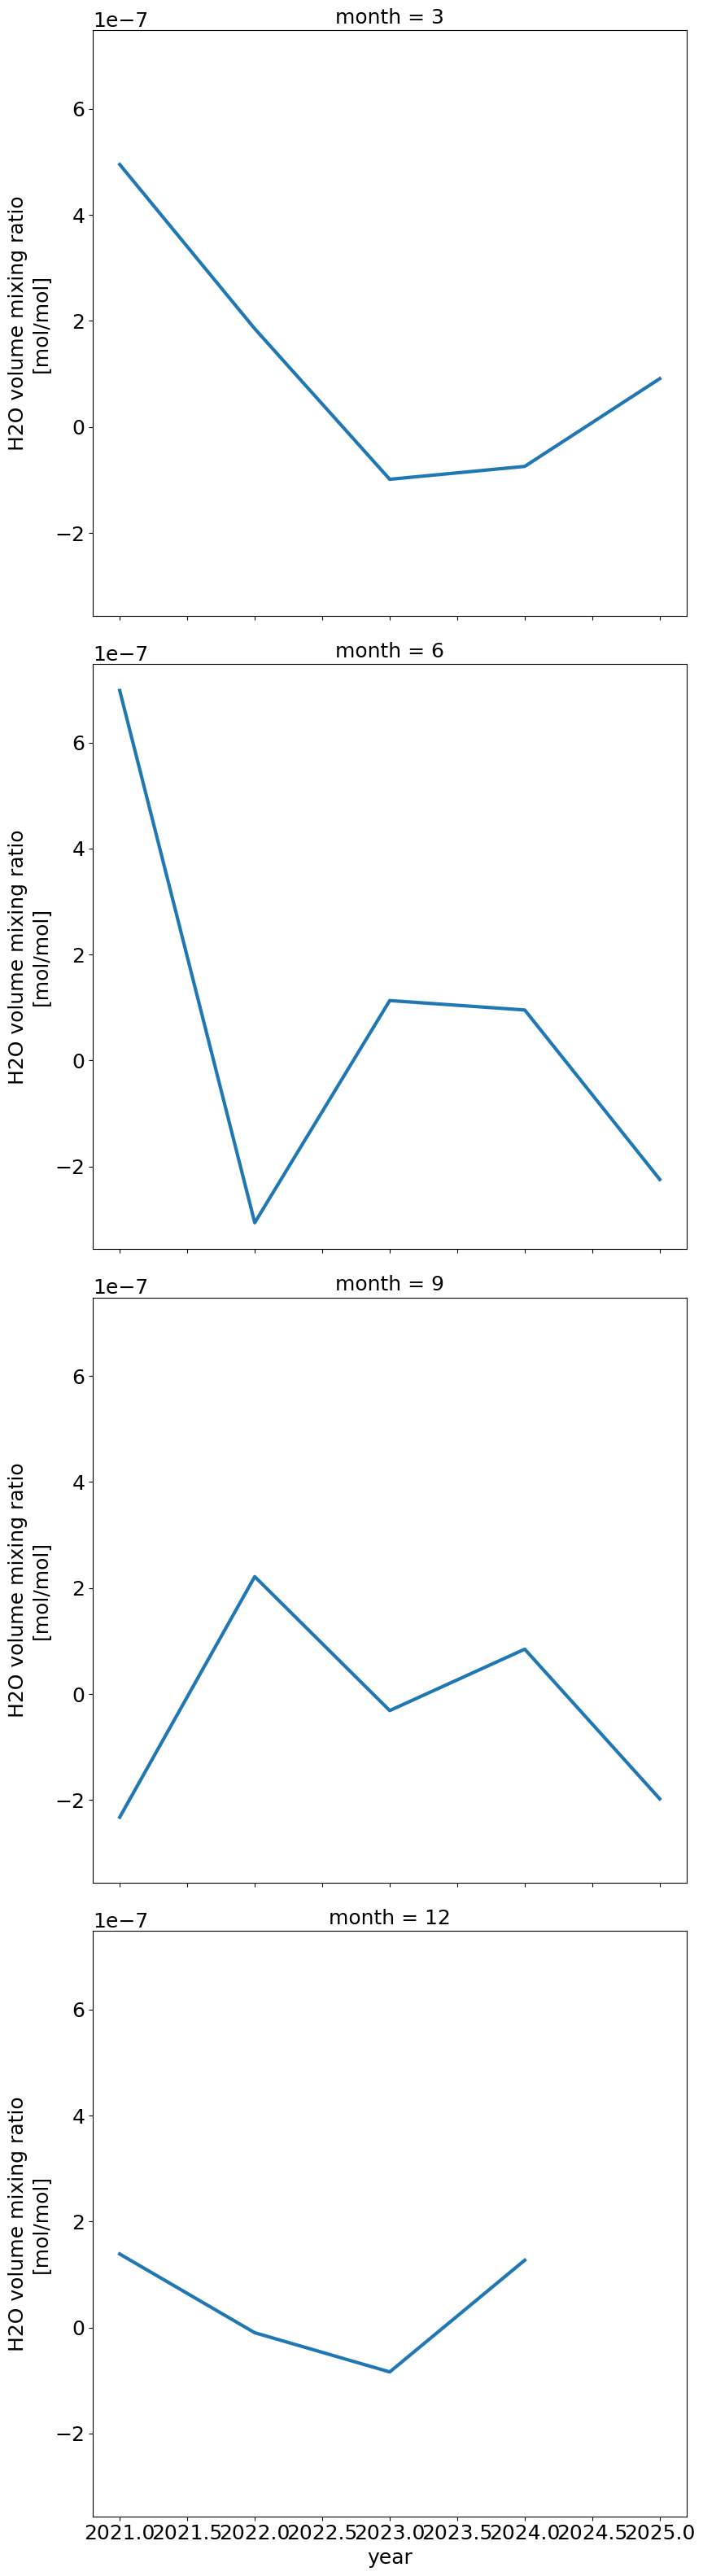

In [22]:
to_monthly(da).plot(row = 'month', size = 8, lw = 3)

In [40]:
what = "OHx_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*"))

In [41]:
infiles_wo

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt22_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt26_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt21_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt25_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt29_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt23_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt27_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt28_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt20_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt24_OHx_mm_zon_2021-2025.nc')]

In [44]:
ds_wo_ohx = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_wo_ohx

/tmp/ipykernel_3184020/407843676.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


<xarray.Dataset> Size: 5MB
Dimensions:  (ens: 10, time: 60, plev: 21, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.04281 0.1112 0.2315 ... 74.06 91.02 110.7
Dimensions without coordinates: ens
Data variables:
    OH_m     (ens, time, plev, lat, lon) float32 5MB nan nan ... 7.885e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 14:29:26 2024: cdo cat Postproc_example-OHx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [45]:
ds_w_ohx = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_w_ohx

/tmp/ipykernel_3184020/407843676.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


<xarray.Dataset> Size: 5MB
Dimensions:  (ens: 10, time: 60, plev: 21, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.04281 0.1112 0.2315 ... 74.06 91.02 110.7
Dimensions without coordinates: ens
Data variables:
    OH_m     (ens, time, plev, lat, lon) float32 5MB 6.741e-12 ... 5.931e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 14:28:51 2024: cdo cat Postproc_example-OHx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

### zonal wind

In [136]:
time_slice = "2024-02"
sel_dict = dict(time=time_slice)
sel_var = 'te_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [103]:
diff

<xarray.DataArray 'u_m' (time: 8, plev: 21, lat: 96, lon: 1)>
array([[[[ 1.27959180e+00],
         [ 2.48538065e+00],
         [ 3.07981968e+00],
         ...,
         [-4.52089310e-03],
         [-1.54515982e-01],
         [-2.00440764e-01]],

        [[ 8.24707747e-01],
         [ 1.56519592e+00],
         [ 1.89058244e+00],
         ...,
         [-2.57146180e-01],
         [-8.84328187e-02],
         [-1.72712922e-01]],

        [[ 1.27667236e+00],
         [ 2.09865141e+00],
         [ 2.12810493e+00],
         ...,
...
         ...,
         [ 7.44902611e-01],
         [ 4.22571898e-01],
         [ 1.50126934e-01]],

        [[-3.70753765e-01],
         [-8.50153148e-01],
         [-1.21058095e+00],
         ...,
         [ 7.84040928e-01],
         [ 4.81096983e-01],
         [ 2.18768120e-01]],

        [[-2.90476322e-01],
         [-7.73818851e-01],
         [-1.22484481e+00],
         ...,
         [ 8.66377831e-01],
         [ 5.68389177e-01],
         [ 2.97735870e-01]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2023-10-31 2023-11-30 ... 2024-05-31
  * lon      (lon) float64 0.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * plev     (plev) float64 0.04281 0.1112 0.2315 0.4259 ... 74.06 91.02 110.7
Attributes:
    long_name:         Zonal wind
    units:             m/s
    code:              10
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

([<matplotlib.axis.YTick at 0x7f16300efc50>,
 [])

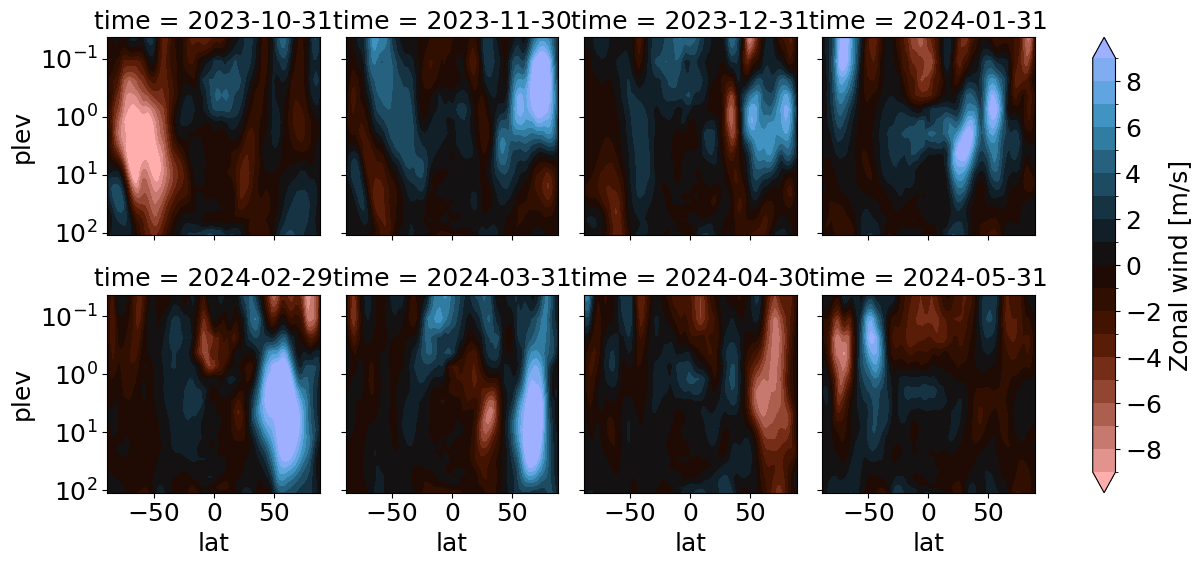

In [105]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

### temperature

In [136]:
time_slice = "2024-02"
sel_dict = dict(time=time_slice)
sel_var = 'te_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

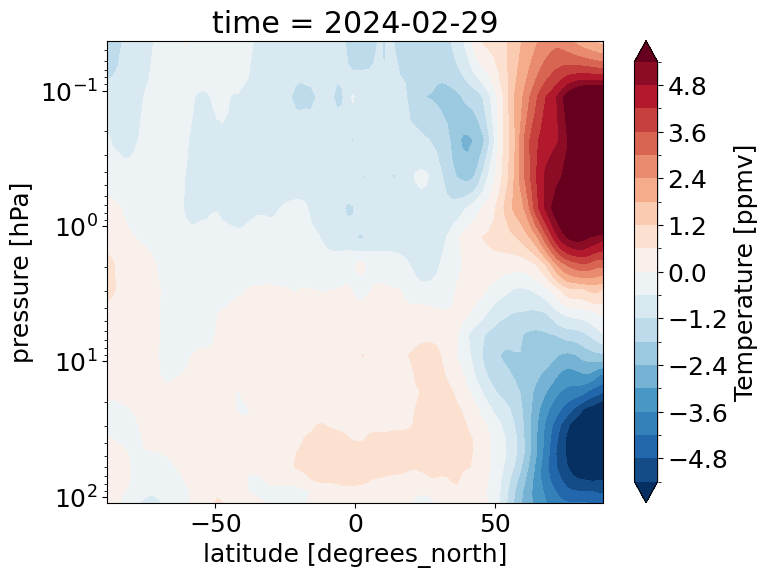

In [138]:
p = diff.squeeze().plot.contourf(yincrease = False, robust = True, size = 6, levels = 21, extend = 'both')
plt.yscale('log')

In [127]:
time_slice = slice("2023-06","2024-04")
sel_dict = dict(time=time_slice, plev = 2.913625e+01)
sel_var = 'te_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [128]:
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))
diff

<xarray.DataArray 'te_m' (time: 11, lat: 96)>
array([[ 0.08561707,  0.0738678 ,  0.08732605, ..., -0.69151306,
        -0.7540436 , -0.784317  ],
       [-0.06277466, -0.07699585, -0.09924316, ..., -0.30722046,
        -0.3081665 , -0.30285645],
       [-0.48031616, -0.46147156, -0.44973755, ..., -0.16169739,
        -0.2908783 , -0.35534668],
       ...,
       [-6.5516205 , -6.522339  , -6.4062195 , ..., -0.1952362 ,
        -0.19995117, -0.20227051],
       [-4.046036  , -4.0288696 , -4.0651855 , ..., -0.2199707 ,
        -0.21444702, -0.2108612 ],
       [ 3.289627  ,  2.9582977 ,  2.571518  , ...,  0.37774658,
         0.3630066 ,  0.359375  ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2023-06-30 2023-07-31 ... 2024-04-30
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
    plev     float64 29.14
Attributes:
    long_name:         Temperature
    units:             K
    code:              9
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

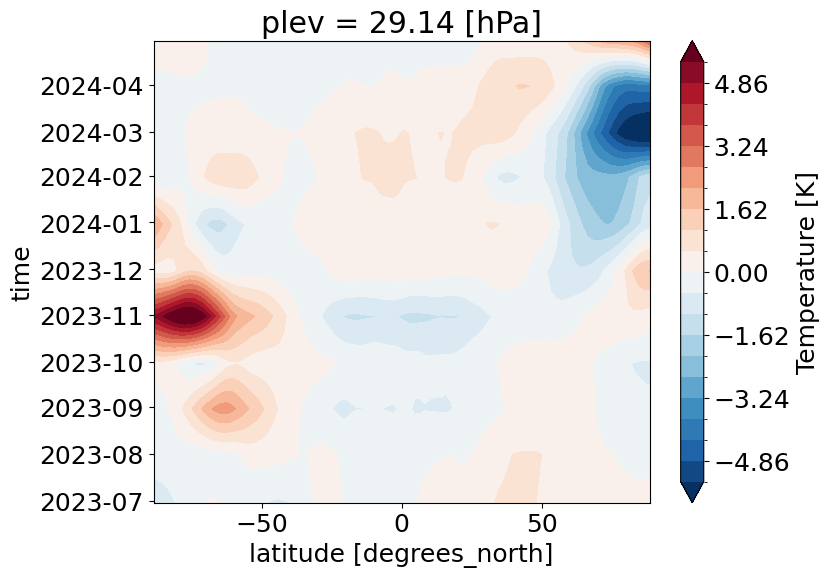

In [129]:
diff.squeeze().plot.contourf(y = 'time', size = 6, levels = 21, vmin = p.colorbar.vmin, vmax = p.colorbar.vmax, extend = 'both', cmap = 'RdBu_r')

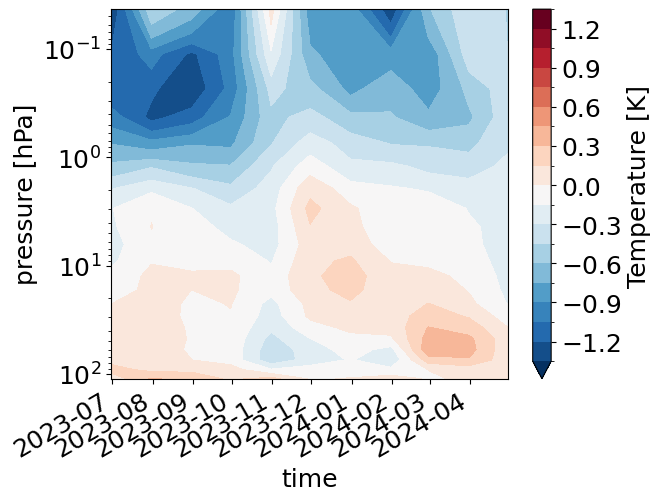

In [144]:
time_slice = slice("2023-06","2024-04")
sel_dict = dict(time=time_slice, lat = slice(70,None))
sel_var = 'te_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).weighted(weights).mean('lat').load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).weighted(weights).mean('lat').load()
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))
diff.plot.contourf(x = 'time', yincrease = False, robust = True, levels = 21)
plt.yscale('log')

/tmp/ipykernel_3184020/1075135327.py:9: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


TE-evolution_2023-2024.pdf


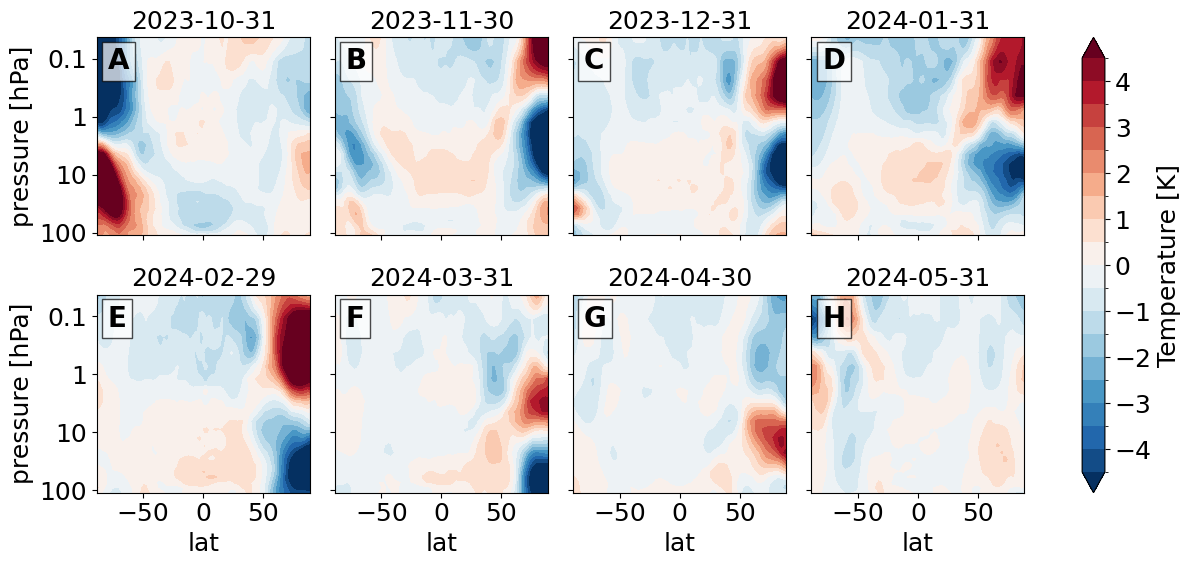

In [59]:
sel_var = 'te_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
p=diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True)

p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')


outfile = f"TE-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

### OHx

/tmp/ipykernel_3184020/2686894252.py:13: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


OHx-evolution_2023-2024.pdf


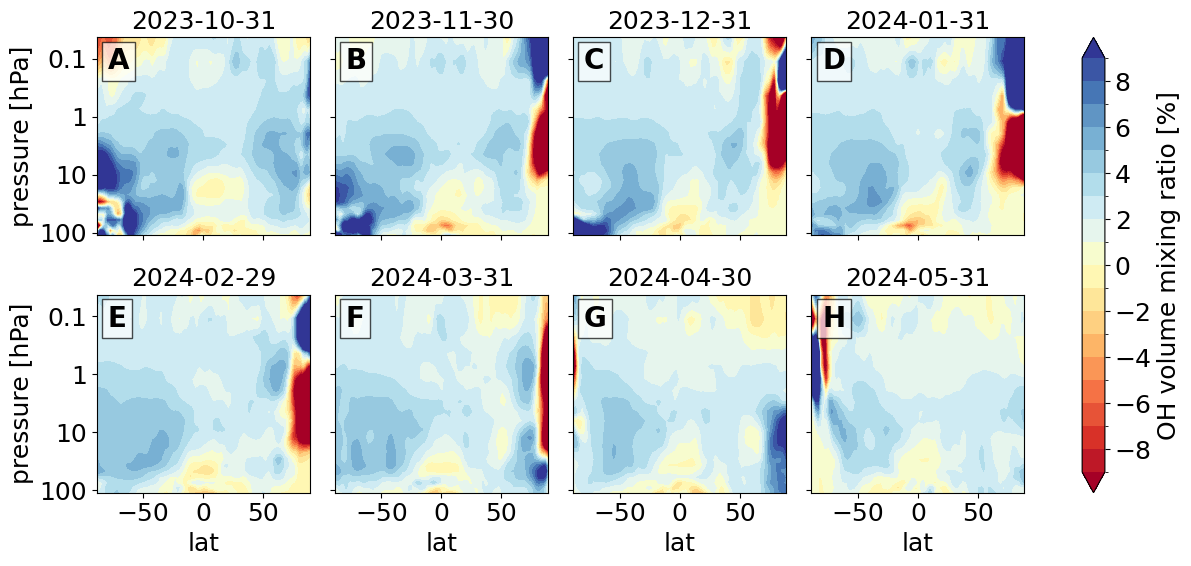

In [51]:
sel_var = 'OH_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

arr1 = ds_w_ohx[sel_var].sel(**sel_dict).mean(['ens'])
diff = (arr1 - ds_wo_ohx[sel_var].sel(**sel_dict).mean(['ens']))/arr1*100
diff.attrs['units'] = '%'
p = diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, cmap="RdYlBu", extend = 'both', robust = True)



p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')
#plt.title('polar uppwer stratosphere')
outfile = f"OHx-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")
#plt.title('polar uppwer stratosphere')

### O3

/tmp/ipykernel_3184020/864030571.py:13: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


O3-evolution_2023-2024.pdf


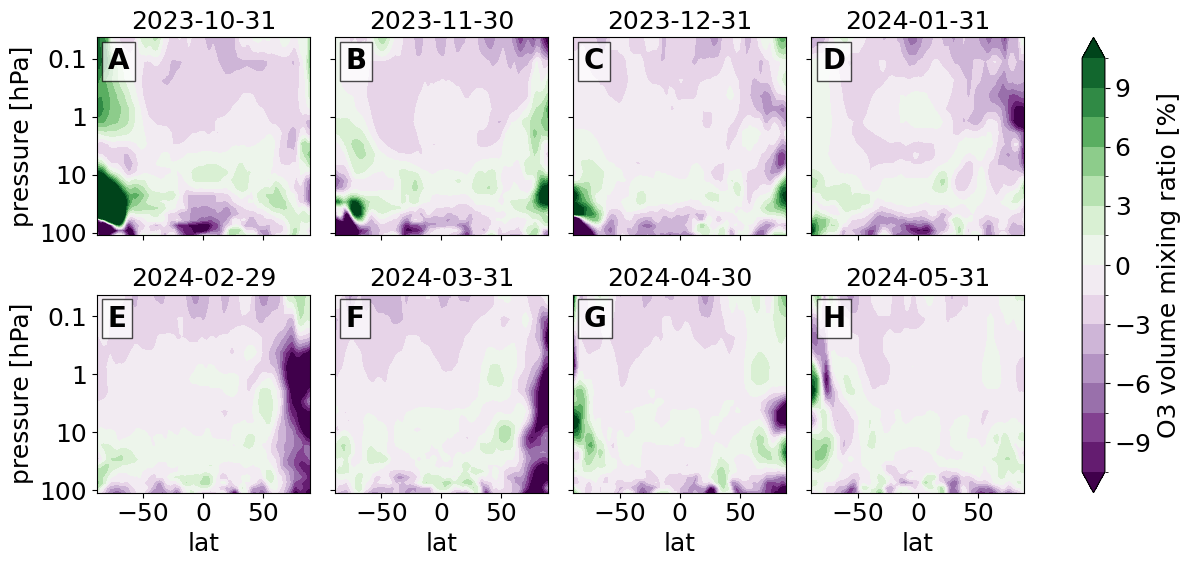

In [54]:
sel_var = 'O3_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

arr1 = ds_w_chem[sel_var].sel(**sel_dict).mean(['ens'])
diff = (arr1 - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))/arr1*100
diff.attrs['units'] = '%'
p = diff.squeeze().plot.contourf(col = 'time', robust = True, levels = 21, yincrease = False, col_wrap = 4, cmap="PRGn", extend = 'both')



p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')
#plt.title('polar uppwer stratosphere')
outfile = f"O3-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")
#plt.title('polar uppwer stratosphere')

### H2O

/tmp/ipykernel_3184020/1425459559.py:12: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for i, ax in enumerate(p.axes.flat):


WV-evolution_2023-2024.pdf


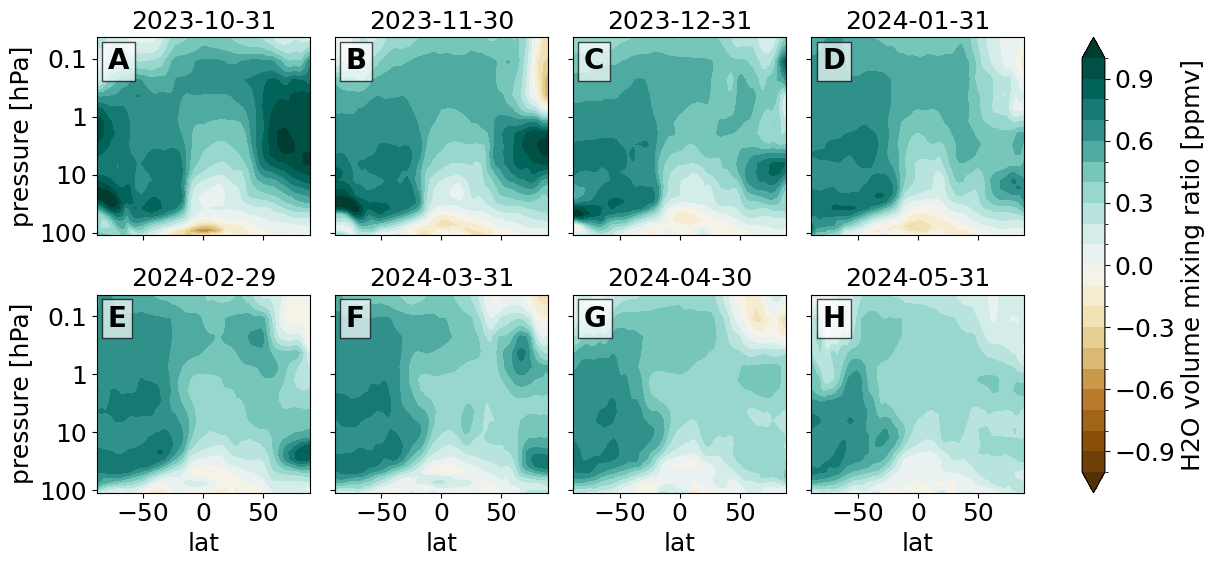

In [35]:
sel_var = 'H2O_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))*1e6
diff.attrs['units'] = 'ppmv'
p = diff.squeeze().plot.contourf(col = 'time', vmax = 1, levels = 21, yincrease = False, col_wrap = 4, cmap="BrBG", extend = 'both')



p.set_titles(template='{value}')

for i, ax in enumerate(p.axes.flat):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    label = ascii_uppercase[i]
    ax.text(
        0.05,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        bbox={"alpha": 0.7, "facecolor": "white"},
    )
    if (i==0) or (i==4):
        ax.set_ylabel('pressure [hPa]')
#plt.title('polar uppwer stratosphere')
outfile = f"WV-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")
#plt.title('polar uppwer stratosphere')

In [259]:
time_slice = "2024-02"
sel_dict = dict(time=time_slice)
sel_var = 'H2O_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [260]:
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))* 1e6
diff.attrs['units'] = 'ppmv'

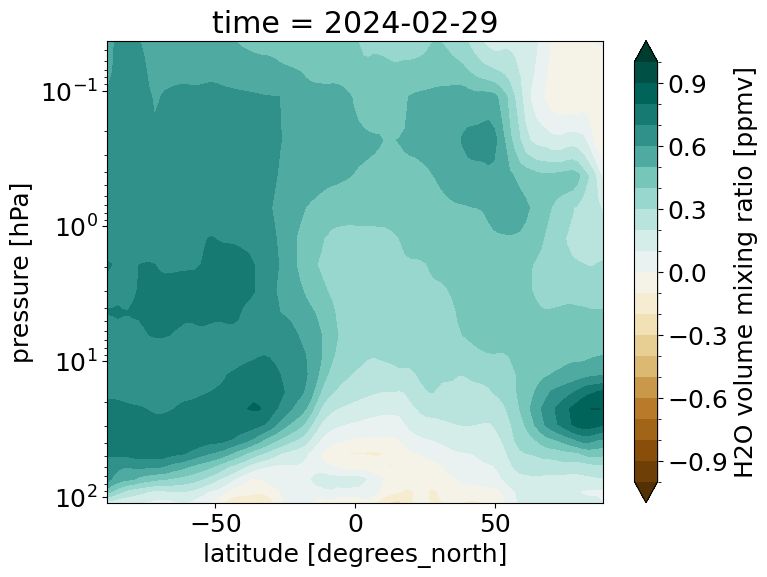

In [261]:
p = diff.squeeze().plot.contourf(yincrease = False, vmax = 1, size = 6, levels = 21, cmap = 'BrBG', extend = 'both')
plt.yscale('log')

In [133]:
time_slice = slice("2023-06","2024-04")
sel_dict = dict(time=time_slice, plev = 2.913625e+01)
sel_var = 'H2O_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [134]:
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))*1e6
diff.attrs['units'] = 'ppmv'

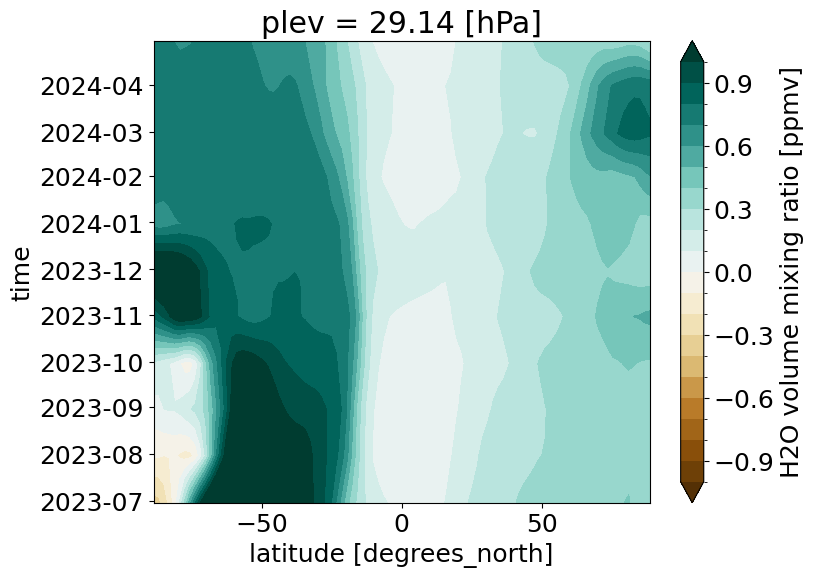

In [135]:
diff.squeeze().plot.contourf(y = 'time', size = 6, levels = 21, vmin = p.colorbar.vmin, vmax = p.colorbar.vmax, extend = 'both', cmap = 'BrBG')

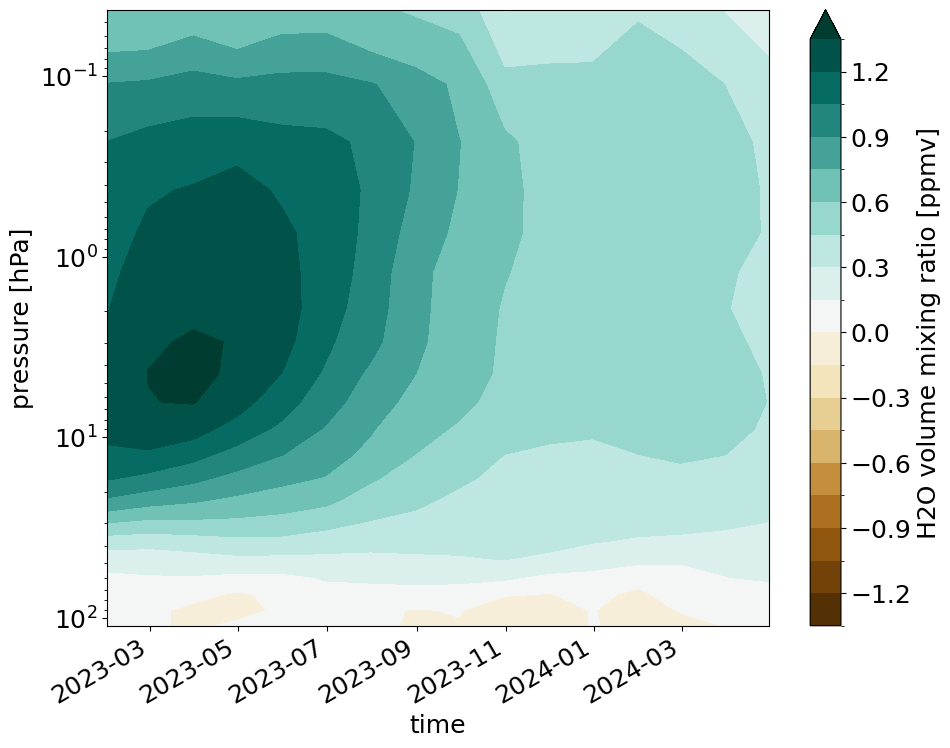

In [147]:
time_slice = slice("2023-01","2024-04")
sel_dict = dict(time=time_slice, lat = slice(70,None))
sel_var = 'H2O_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).weighted(weights)
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).weighted(weights)
diff = (ds_w_chem_sel.mean(['lat',"ens",'lon']) - ds_wo_chem_sel.mean(['lat',"ens",'lon']))*1e6
diff.attrs['units'] = 'ppmv'
diff.plot.contourf(x = 'time', yincrease = False, robust = True, levels = 21, cmap = 'BrBG', size = 8)
plt.yscale('log')

### O3

([<matplotlib.axis.YTick at 0x7f32070bc390>,
 [])

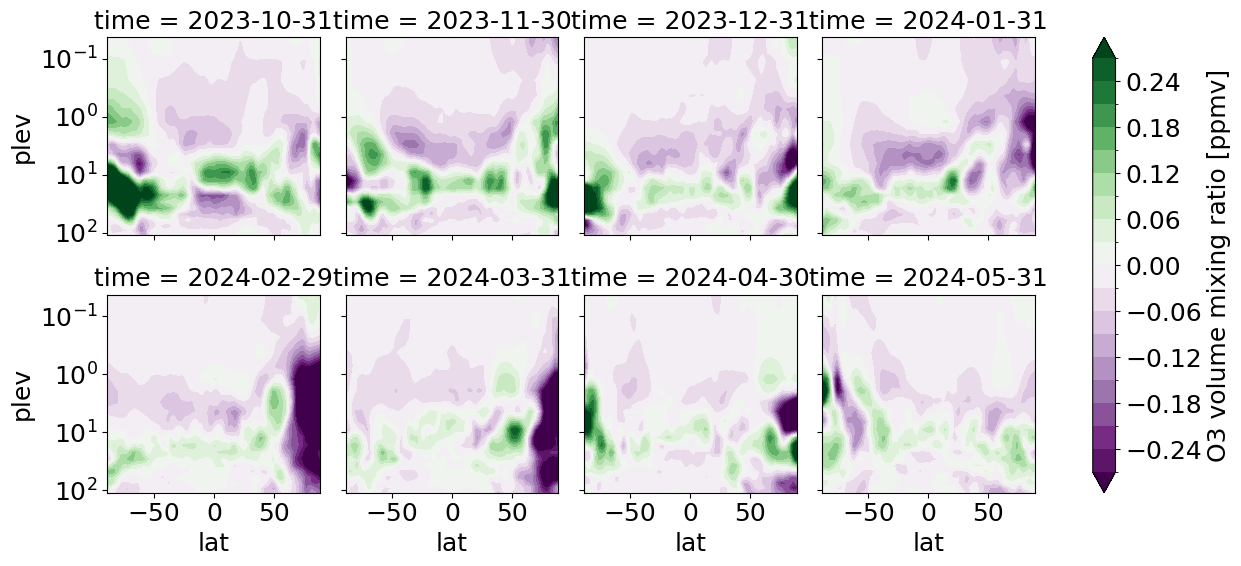

In [276]:
sel_var = 'O3_m'
sel_dict = dict(time = slice('2023-10', '2024-05'))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))*1e6
diff.attrs['units'] = 'ppmv'
diff.squeeze().plot.contourf(col = 'time', robust = True, levels = 21, yincrease = False, col_wrap = 4, cmap="PRGn",)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

In [107]:
time_slice = "2024-02"
sel_dict = dict(time=time_slice)
sel_var = 'O3_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [108]:
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))* 1e6
diff.attrs['units'] = 'ppmv'
diff

<xarray.DataArray 'O3_m' (time: 1, plev: 21, lat: 96)>
array([[[ 0.02467755,  0.03897639,  0.04502783, ..., -0.00166249,
         -0.00085616, -0.00115124],
        [ 0.03061359,  0.0251448 ,  0.029847  , ..., -0.00773389,
         -0.00759007, -0.00681365],
        [-0.04564413, -0.03805212, -0.03466539, ..., -0.01261805,
         -0.01316022, -0.01479583],
        ...,
        [-0.21173242, -0.21771893, -0.22791846, ...,  0.07016309,
          0.08594418,  0.10057203],
        [-0.18668357, -0.18635444, -0.18131152, ...,  0.00690807,
          0.03225898,  0.04531284],
        [-0.17881052, -0.16547926, -0.14800161, ..., -0.01207974,
         -0.00845483, -0.01170088]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2024-02-29
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * plev     (plev) float64 0.04281 0.1112 0.2315 0.4259 ... 74.06 91.02 110.7
Attributes:
    long_name:         O3 volume mixing ratio
    units:             ppmv
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

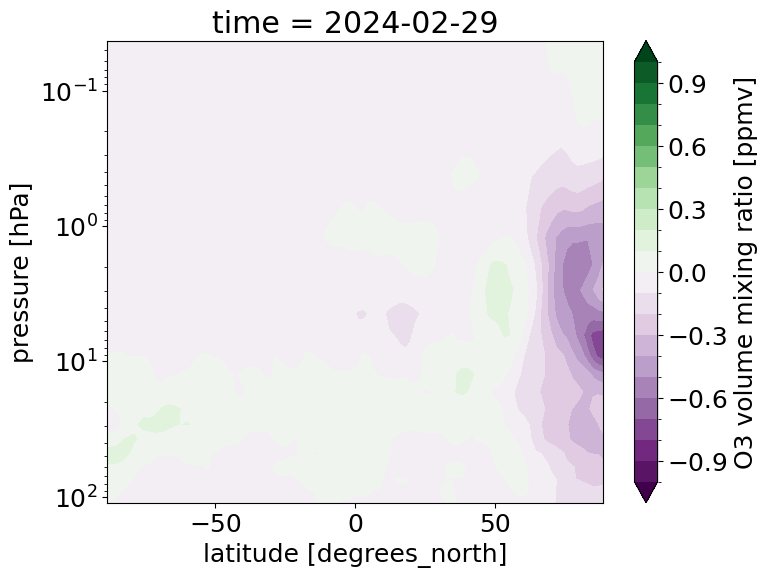

In [109]:
p = diff.squeeze().plot.contourf(yincrease = False, vmax = 1, size = 6, levels = 21, cmap = 'PRGn', extend = 'both')
plt.yscale('log')

In [103]:
time_slice = slice("2023-11","2024-04")
sel_dict = dict(time=time_slice, plev = 2.913625e+01)
sel_var = 'O3_m'
ds_w_chem_sel = ds_w_chem[sel_var].sel(**sel_dict).load()
ds_wo_chem_sel = ds_wo_chem[sel_var].sel(**sel_dict).load()

In [104]:
diff = (ds_w_chem_sel.mean(["ens",'lon']) - ds_wo_chem_sel.mean(["ens",'lon']))*1e6
diff.attrs['units'] = 'ppmv'
diff

<xarray.DataArray 'O3_m' (time: 6, lat: 96)>
array([[ 4.64295238e-01,  4.38655674e-01,  4.26422060e-01,
         3.88504535e-01,  3.30554932e-01,  2.62945145e-01,
         2.04595610e-01,  1.51806951e-01,  1.14346221e-01,
         1.00495070e-01,  8.42467248e-02,  7.66212940e-02,
         7.75776207e-02,  7.41470084e-02,  7.33789429e-02,
         7.27836788e-02,  6.89437911e-02,  6.07979000e-02,
         4.53205742e-02,  6.74890541e-03, -2.44522206e-02,
        -2.22044028e-02, -8.78480915e-03,  4.64069657e-03,
         2.64371913e-02,  4.13983800e-02,  4.01314534e-02,
         2.77450457e-02,  1.74509287e-02,  2.18547024e-02,
         3.70791890e-02,  3.98149490e-02,  1.93772390e-02,
        -7.80664757e-03, -2.65613385e-02, -3.32797766e-02,
        -4.92682382e-02, -5.46883717e-02, -5.46269789e-02,
        -5.04414849e-02, -4.82555144e-02, -3.94434221e-02,
        -3.25649120e-02, -2.82711890e-02, -3.20851542e-02,
        -2.82043405e-02, -2.42812354e-02, -1.46578718e-02,
        -3.27145238e-03, -3.61751509e-03, -1.12145245e-02,
        -8.91213864e-03, -2.24463292e-03, -5.28416422e-04,
         1.36833475e-03,  4.26280173e-03,  1.72381084e-02,
         4.14056554e-02,  7.65476227e-02,  1.03326328e-01,
...
        -1.80198178e-02, -2.03131102e-02, -2.02157926e-02,
        -1.61908250e-02, -1.97924245e-02, -3.43789011e-02,
        -4.57744151e-02, -4.13274392e-02, -3.81342024e-02,
        -3.32061052e-02, -3.87817621e-02, -4.93473634e-02,
        -4.98607717e-02, -4.22919579e-02, -4.58185226e-02,
        -3.74557190e-02, -3.19078043e-02, -3.29691842e-02,
        -3.41619849e-02, -3.09505593e-02, -2.91734077e-02,
        -3.86476144e-02, -3.92610654e-02, -3.48863974e-02,
        -2.90101524e-02, -2.18865350e-02, -2.00939216e-02,
        -2.59992704e-02, -2.51438897e-02, -4.86397743e-03,
         1.52858775e-02,  2.17401069e-02,  2.24586073e-02,
         2.95781326e-02,  4.26880419e-02,  5.15192375e-02,
         3.84598039e-02,  1.27706695e-02, -6.77300710e-03,
        -1.48802428e-02, -9.85892257e-04,  4.45834314e-03,
         5.89670893e-03,  2.01771408e-02,  4.25798148e-02,
         6.09702505e-02,  9.35510769e-02,  1.06511377e-01,
         9.37193334e-02,  8.53281096e-02,  9.06268284e-02,
         1.12813272e-01,  1.23969130e-01,  1.13388523e-01,
         7.74334669e-02,  1.86355468e-02, -2.84899212e-02,
        -5.13771288e-02, -5.04730903e-02, -4.44754288e-02]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2023-11-30 2023-12-31 ... 2024-04-30
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
    plev     float64 29.14
Attributes:
    long_name:         O3 volume mixing ratio
    units:             ppmv
    code:              11
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

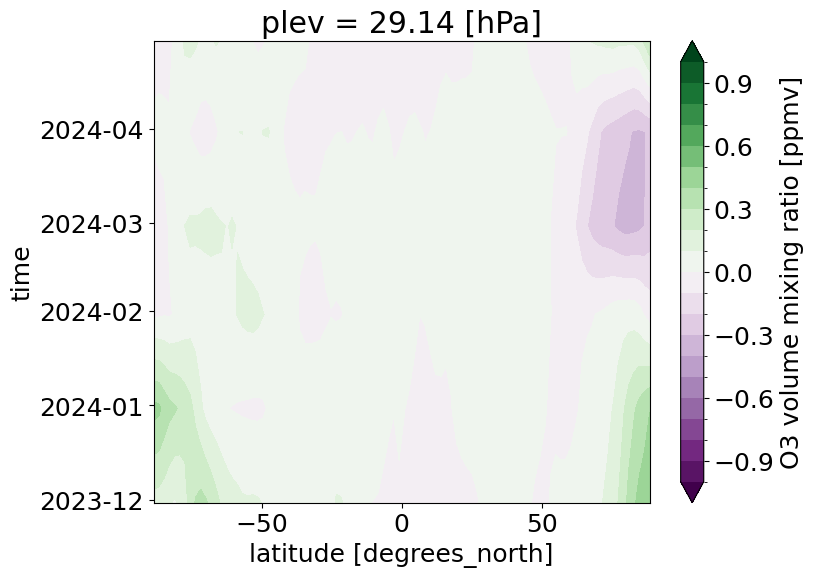

In [106]:
diff.squeeze().plot.contourf(y = 'time', size = 6, levels = 21, vmin = p.colorbar.vmin, vmax = p.colorbar.vmax, extend = 'both', cmap = 'PRGn')

# RRTMG

In [7]:
what = "chem_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*"))

In [16]:
ds_w_chem = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=None, lower_limit = None).sortby('plev', ascending=False)
    .load()
)
ds_w_chem

/tmp/ipykernel_970206/407843676.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


<xarray.Dataset>
Dimensions:  (time: 60, lon: 1, lat: 96, plev: 47, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 0.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * plev     (plev) float64 1.009e+03 995.4 971.4 ... 0.1112 0.04281 0.009946
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 244.6 246.3 ... 181.7 181.9
    u_m      (ens, time, plev, lat, lon) float32 -2.329 -2.021 ... -3.364 -1.813
    O3_m     (ens, time, plev, lat, lon) float32 3.621e-08 ... 4.087e-08
    H2O_m    (ens, time, plev, lat, lon) float32 0.0004767 ... 4.499e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Mar 12 10:25:13 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [15]:
ds_wo_chem = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=None, lower_limit = None).sortby('plev', ascending=False)
    .load()
)
ds_wo_chem

/tmp/ipykernel_970206/407843676.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


<xarray.Dataset>
Dimensions:  (time: 60, lon: 1, lat: 96, plev: 47, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 0.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * plev     (plev) float64 1.009e+03 995.4 971.4 ... 0.1112 0.04281 0.009946
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 nan nan nan ... 180.9 180.4
    u_m      (ens, time, plev, lat, lon) float32 nan nan nan ... 2.075 2.074
    O3_m     (ens, time, plev, lat, lon) float32 nan nan ... 4.208e-08 4.212e-08
    H2O_m    (ens, time, plev, lat, lon) float32 nan nan ... 4.441e-06 4.493e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Thu Feb 29 16:07:22 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [12]:
import konrad

In [10]:
ds_w_chem.plev.values

array([9.94600000e-03, 4.28060000e-02, 1.11230000e-01, 2.31491000e-01,
       4.25850000e-01, 7.35523000e-01, 1.21531800e+00, 1.92916100e+00,
       2.95713900e+00, 4.40009900e+00, 6.37481300e+00, 9.01090100e+00,
       1.24506300e+01, 1.68458300e+01, 2.23543700e+01, 2.91362500e+01,
       3.74306290e+01, 4.75176610e+01, 5.96433100e+01, 7.40594420e+01,
       9.10192100e+01, 1.10654847e+02, 1.32388245e+02, 1.55780552e+02,
       1.81150357e+02, 2.08656353e+02, 2.38316096e+02, 2.70127453e+02,
       3.03988207e+02, 3.39820442e+02, 3.77493246e+02, 4.16796710e+02,
       4.57620037e+02, 4.99878639e+02, 5.43389949e+02, 5.87954623e+02,
       6.33387790e+02, 6.79449722e+02, 7.25778739e+02, 7.71925845e+02,
       8.17340378e+02, 8.61204472e+02, 9.02421403e+02, 9.39705791e+02,
       9.71422102e+02, 9.95424432e+02, 1.00909997e+03])

In [33]:
plev = ds_w_chem.plev.values*100.
atmosphere = konrad.atmosphere.Atmosphere(plev)
ds_atmo = atmosphere.to_dataset()#['CO2']#.plot()

In [201]:
def polar_sel(ds):
    ds_sel = ds[['O3_m','te_m','H2O_m']].sel(time = '2024-01', lat = slice(None,60))
    weights = np.cos(np.deg2rad(ds_sel.lat))
    weights.name = "weights"
    (ds_sel['H2O_m'].sel(plev = slice(100,None))*1e6).plot.hist()
    ds_sel_pcap = ds_sel.weighted(weights).mean(['lat','ens']).squeeze()
    ds_sel_pcap['plev'] = ds_sel_pcap.plev.values*100.
    return ds_sel_pcap

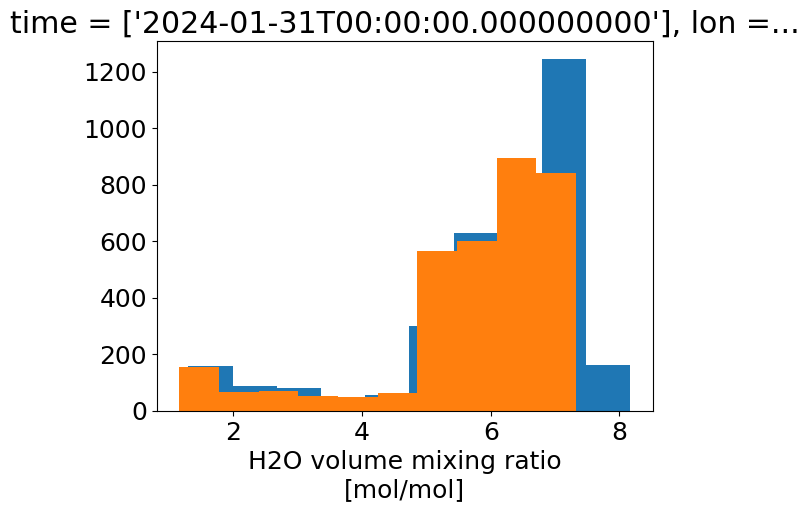

In [202]:
pcap_w = polar_sel(ds_w_chem)#[['O3_m','te_m','H2O_m']].sel(time = '2024-02', lat = slice(None,60))
pcap_wo = polar_sel(ds_wo_chem)

In [119]:
diff_pcap = pcap_w-pcap_wo

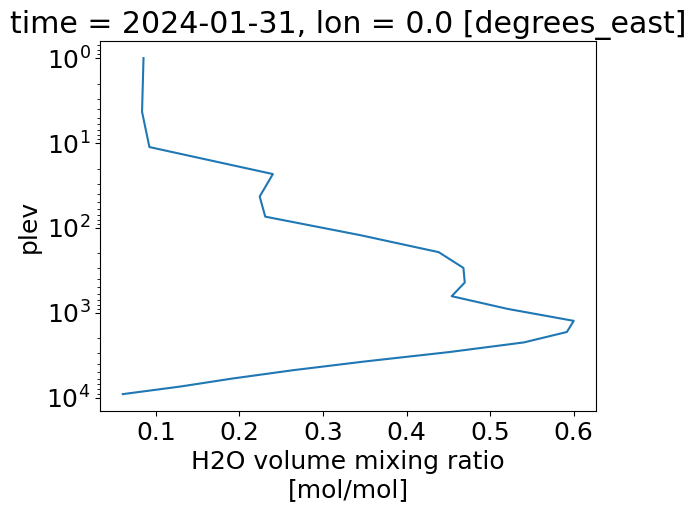

In [120]:
(diff_pcap['H2O_m'].sel(plev = slice(10000,None))*1e6).plot(yincrease = False, y = 'plev')
plt.yscale('log')

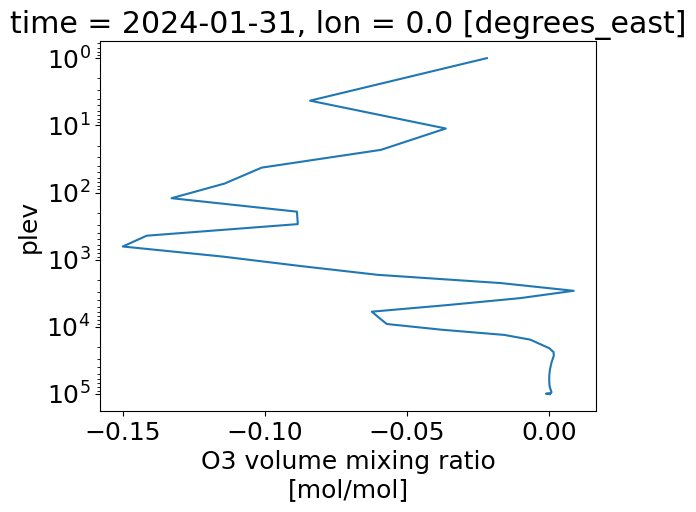

In [122]:
(diff_pcap['O3_m'].sel(plev = slice(None,None))*1e6).plot(yincrease = False, y = 'plev')
plt.yscale('log')

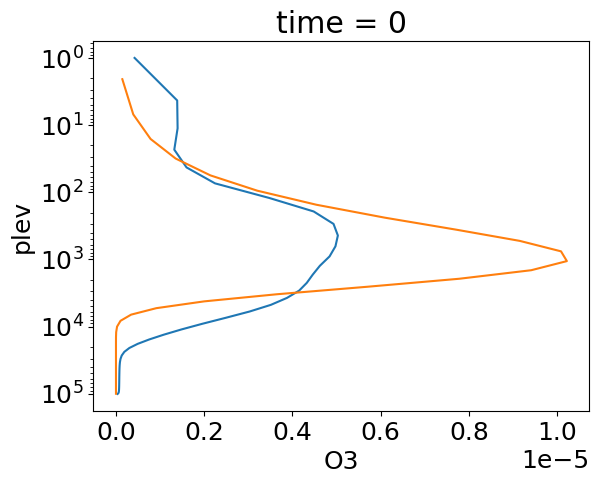

In [34]:
pcap_w['O3_m'].plot(yincrease = False, y = 'plev')
ds_atmo['O3'].plot(yincrease = False, y = 'plev')
plt.yscale('log')

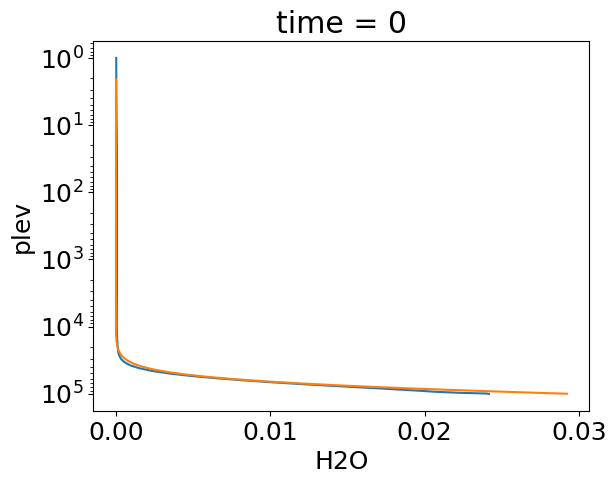

In [128]:
(pcap_w['H2O_m']*10).plot(yincrease = False, y = 'plev')
ds_atmo['H2O'].plot(yincrease = False, y = 'plev')
plt.yscale('log')

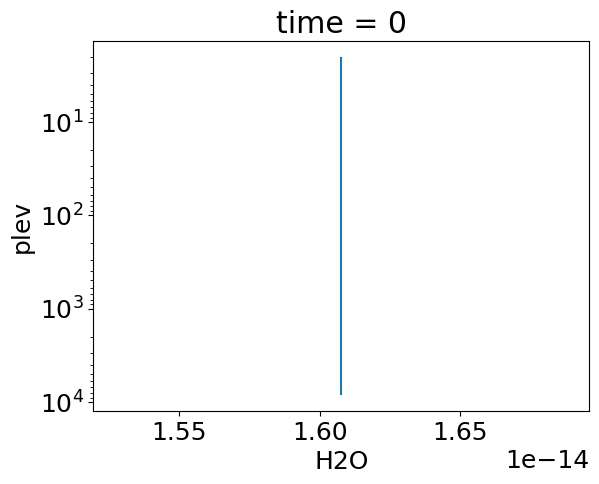

In [94]:
#pcap_w['H2O_m'].sel(plev = slice(10000,None)).plot(yincrease = False, y = 'plev')
ds_atmo['H2O'].sel(plev = slice(10000,None)).plot(yincrease = False, y = 'plev')
plt.yscale('log')

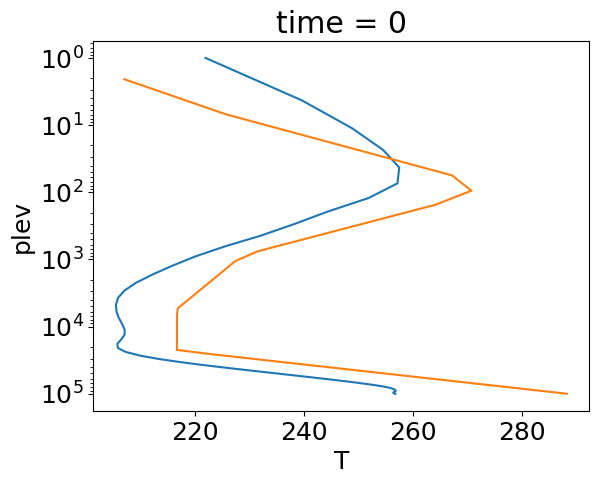

In [37]:
pcap_w['te_m'].plot(yincrease = False, y = 'plev')
ds_atmo['T'].plot(yincrease = False, y = 'plev')
plt.yscale('log')

In [183]:
def rad_cal(pcap, forc_switch, zenith_angle=85):
    plev = pcap.plev.values
    atmosphere = konrad.atmosphere.Atmosphere(plev)
    #print(pcap['O3_m'].squeeze().values[np.newaxis,:])
    #atmosphere['O3'][:] = pcap['O3_m'].squeeze().values[np.newaxis,1:]
    atmosphere['H2O'][:] = pcap['H2O_m'].squeeze().values[np.newaxis,1:]#*10
    atmosphere['T'][:] = pcap['te_m'].squeeze().values[np.newaxis,1:]

    surface = konrad.surface.SlabOcean.from_atmosphere(atmosphere)
    surface['temperature'][:] = [300]
# Create cloud component (here clear-sky).
    cloud = konrad.cloud.ClearSky.from_atmosphere(atmosphere)
    
    # Create aerosol component (here clear-sky).
    #aerosol = konrad.aerosol.NoAerosol(atmosphere)
    
    # Setup the RRTMG radiation component (choose zenith angle and solar constant).
    rrtmg = konrad.radiation.RRTMG(zenith_angle=zenith_angle)#47.88)
    rrtmg.calc_radiation(atmosphere, surface, cloud)#, aerosol)  # Actual RT simulation
    print(rrtmg['sw_flxu'].shape)
    ds_out_hr = xr.Dataset(
        data_vars=dict(
            lw_htngrt=(["plev"], rrtmg['lw_htngrt'].squeeze()),
            sw_htngrt=(["plev"], rrtmg['sw_htngrt'].squeeze()),
        ),
        coords=dict(plev = pcap.plev.values[1:]),
    )
    ds_out_fluxes = xr.Dataset(
        data_vars=dict(
            sw_flxu=(["plev"], rrtmg['sw_flxu'].squeeze()),
            sw_flxd=(["plev"], rrtmg['sw_flxd'].squeeze()),
            lw_flxu=(["plev"], rrtmg['lw_flxu'].squeeze()),
            lw_flxd=(["plev"], rrtmg['lw_flxd'].squeeze()),
        ),
        coords=dict(plev = pcap.plev.values[:]),
    )
    return ds_out_hr, ds_out_fluxes#(rrtmg['lw_htngrt'].squeeze(), rrtmg['sw_htngrt'].squeeze)

In [184]:
ds_hr_w, ds_fluxes_w = rad_cal(pcap_w)
ds_hr_wo, ds_fluxes_wo = rad_cal(pcap_wo)

(1, 47)
(1, 47)


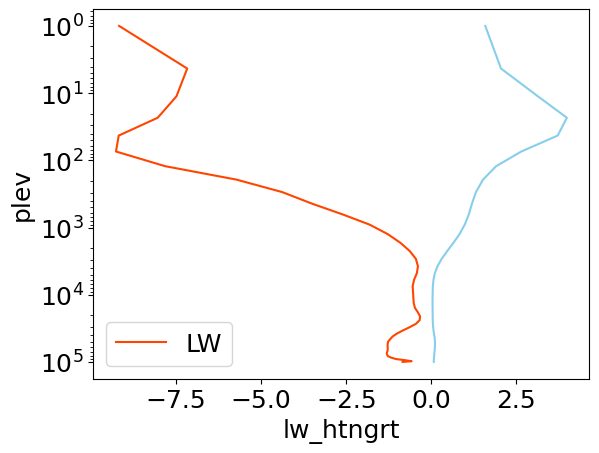

In [171]:
ds_hr_w['sw_htngrt'].plot(yincrease = False, y = 'plev', color = 'skyblue')
ds_hr_w['lw_htngrt'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW')
plt.legend()

plt.yscale('log')

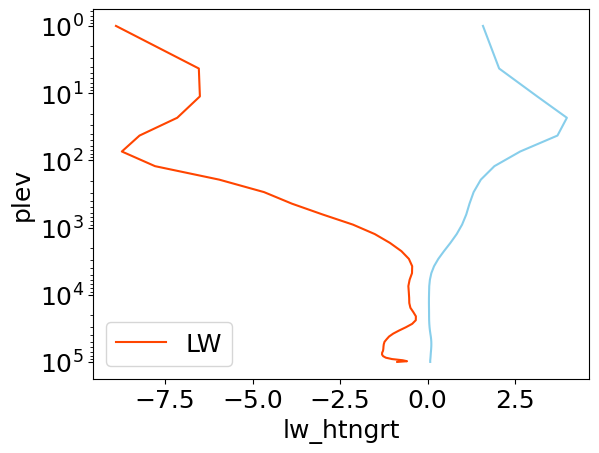

In [160]:
ds_rad_wo['sw_htngrt'].plot(yincrease = False, y = 'plev', color = 'skyblue')
ds_rad_wo['lw_htngrt'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW')
plt.legend()

plt.yscale('log')

In [175]:
ds_hr_wo

<xarray.Dataset>
Dimensions:  (plev: 47)
Coordinates:
  * plev     (plev) float64 1.009e+05 9.954e+04 9.714e+04 ... 11.12 4.281 0.9946
Data variables:
    sw_flxu  (plev) float64 5.449 5.502 5.597 5.727 ... 14.04 14.05 14.05 14.05
    sw_flxd  (plev) float64 27.25 27.42 27.71 28.11 ... 48.0 48.05 48.07 48.07
    lw_flxu  (plev) float64 250.2 249.4 248.3 247.9 ... 196.7 196.6 196.6 196.6
    lw_flxd  (plev) float64 169.4 167.2 164.4 161.4 ... 0.1328 0.05371 0.0

In [192]:
diff = ds_hr_w-ds_hr_wo

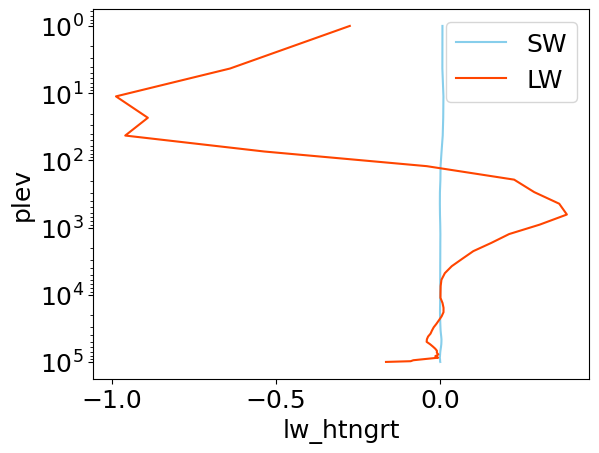

In [193]:
diff['sw_htngrt'].plot(yincrease = False, y = 'plev', color = 'skyblue', label  = 'SW')
diff['lw_htngrt'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW')
plt.legend()

plt.yscale('log')

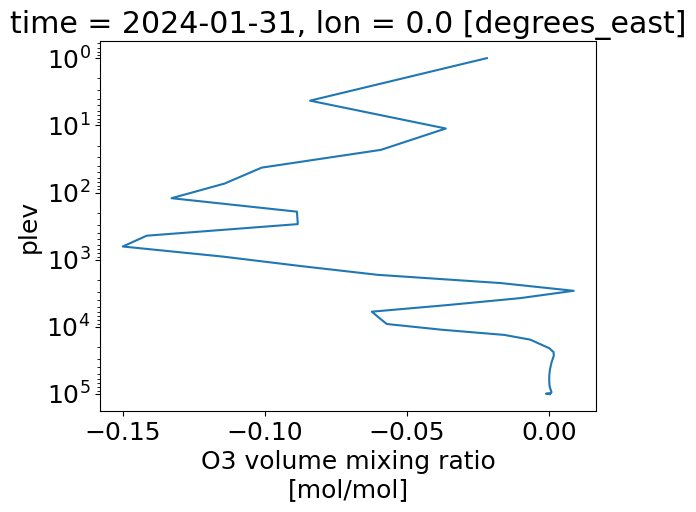

In [187]:
(diff_pcap['O3_m'].sel(plev = slice(None,None))*1e6).plot(yincrease = False, y = 'plev')
plt.yscale('log')

In [190]:
diff = ds_fluxes_w-ds_fluxes_wo
diff

<xarray.Dataset>
Dimensions:  (plev: 47)
Coordinates:
  * plev     (plev) float64 1.009e+05 9.954e+04 9.714e+04 ... 11.12 4.281 0.9946
Data variables:
    sw_flxu  (plev) float64 -0.01823 -0.01829 -0.01834 ... -0.01929 -0.01929
    sw_flxd  (plev) float64 -0.09116 -0.09103 -0.09264 ... -2.654e-05 -6.163e-08
    lw_flxu  (plev) float64 2.759e-05 0.3409 0.7449 ... -1.002 -1.005 -1.007
    lw_flxd  (plev) float64 2.823 2.896 3.044 3.015 ... 0.0107 0.003069 0.0

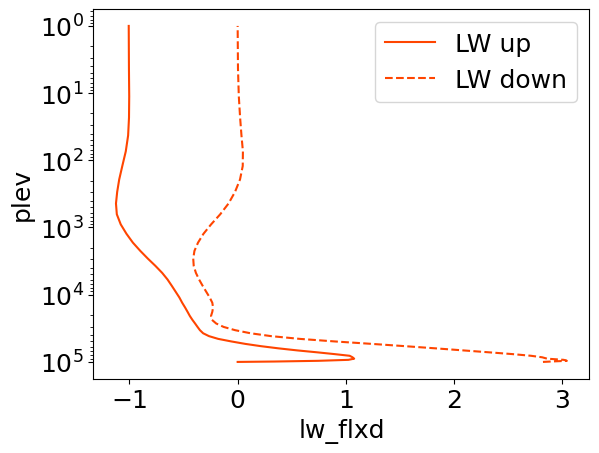

In [191]:
diff['lw_flxu'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW up')
diff['lw_flxd'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW down', ls='dashed')

plt.legend()

plt.yscale('log')

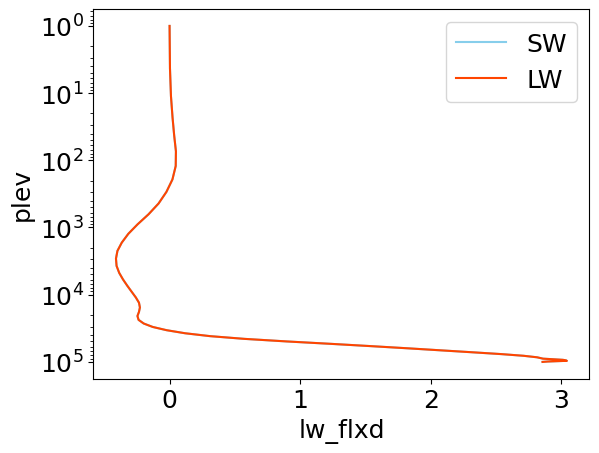

In [182]:
diff['lw_flxd'].plot(yincrease = False, y = 'plev', color = 'skyblue', label  = 'SW')
diff['lw_flxd'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW')
plt.legend()

plt.yscale('log')